# Case Study 1: Building a Mean-Variance Portfolio Pipeline

STAT 4170 — [Your Name]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

RNG_SEED = 1
np.random.seed(RNG_SEED)

TICKERS = ["XLC", "XLY", "XLP", "XLE", "XLF", "XLV", "XLI", "XLB", "XLRE", "XLK", "XLU"]
MARKET = "SPY"
ALL_TICKERS = TICKERS + [MARKET]

## Section 1 - Data Pipeline

In [2]:
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
RETURNS_CACHE_PATH = DATA_DIR / "sector_etf_returns.csv"
HISTORY_START = "2018-01-01"  # before all 12 tickers existed; XLC (2018) and XLRE (2015) trim the front


def _most_recent_expected_trading_day() -> pd.Timestamp:
    """Most recent trading day whose closing price should already be available.

    Approximates the NYSE calendar with a Mon-Fri rule and a 4:00pm US/Eastern
    close (no holiday calendar). On a market holiday this triggers one harmless
    extra refresh that just reconfirms the prior close -- it never serves stale
    data silently.
    """
    now_et = datetime.now(ZoneInfo("America/New_York"))
    day = pd.Timestamp(now_et.date())
    if now_et.hour < 16:
        day -= pd.Timedelta(days=1)
    while day.weekday() >= 5:  # roll weekends back to Friday
        day -= pd.Timedelta(days=1)
    return day.normalize()


def get_sector_returns(tickers=ALL_TICKERS, start=HISTORY_START, cache_path=RETURNS_CACHE_PATH, force_refresh=False):
    """Load daily simple returns for `tickers` since `start`, using a disk cache.

    On the first call (or whenever the cache is missing or stale), downloads
    adjusted daily closes via yfinance, converts to simple returns
    r_t = P_t / P_{t-1} - 1, and writes the returns (not prices) to
    `cache_path`. Later calls read the CSV directly and only hit the network
    again once the cached data no longer reaches the most recent expected
    trading day.
    """
    expected_latest = _most_recent_expected_trading_day()

    if cache_path.exists() and not force_refresh:
        cached = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        if cached.index.max() >= expected_latest:
            return cached

    prices = yf.download(tickers, start=start, auto_adjust=True, progress=False)["Close"]
    prices = prices[tickers].sort_index()
    returns = prices.pct_change().dropna(how="any")
    returns.to_csv(cache_path)
    return returns


returns = get_sector_returns()
print(returns.shape)
returns.head(10)

(2059, 12)


Ticker,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU,SPY
Date,,,,,,,,,,,,
2018-06-20,0.012410,0.004741,0.000979,0.004415,-0.002559,0.002121,0.000682,-0.003249,0.010794,0.002100,0.000797,0.001706
2018-06-21,-0.006129,-0.007123,0.001957,-0.018516,-0.002933,-0.005762,-0.012554,-0.010634,0.005967,-0.007684,0.003385,-0.006269
2018-06-22,0.004376,-0.001704,0.008201,0.019951,-0.004779,0.004495,0.003455,0.014563,0.008742,-0.003238,0.006944,0.001823
2018-06-25,-0.020598,-0.021739,0.005036,-0.020093,-0.010713,-0.009184,-0.012671,-0.015550,-0.002476,-0.020763,0.016552,-0.013612
2018-06-26,0.001658,0.007162,-0.004240,0.012629,-0.003361,-0.003090,0.003767,0.003818,0.005275,0.004039,0.001163,0.002214
2018-06-27,-0.008721,-0.012947,-0.002129,0.013410,-0.012364,-0.008463,-0.008060,-0.003112,-0.002778,-0.013648,0.004840,-0.008284
2018-06-28,0.009979,0.007852,0.000000,-0.001323,0.008725,0.001322,0.001401,0.003816,0.009904,0.012234,-0.000386,0.005717
2018-06-29,-0.001210,0.001741,-0.000582,0.006227,0.000000,0.002041,0.002098,0.003456,0.002451,-0.000431,0.001542,0.001440
2018-07-02,0.006259,0.001372,-0.005822,-0.014748,0.004889,0.003115,0.002234,-0.005338,-0.005808,0.008925,0.007121,0.002138


**Return convention.** We use daily **simple (linear) returns**, $r_t = P_t / P_{t-1} - 1$, for every ticker throughout this notebook (not log returns).

**Cache design and invalidation logic.** `get_sector_returns` caches the derived returns (not raw prices) to `data/sector_etf_returns.csv`, a path relative to the notebook so it works on any machine. The first call downloads adjusted daily closes for all 12 tickers, converts them to simple returns, drops the leading `NaN` row from `pct_change`, and writes the result to disk. Later calls read the CSV first and compare the last cached date to `_most_recent_expected_trading_day()`, which approximates "the last trading day that should already have closed" using a Mon-Fri, 4:00pm US/Eastern rule. If the cache already reaches that date, the function returns it with no network call; otherwise it re-downloads. So a grader with no cache always gets a fresh download on the first run, and re-running later the same day (or any day with no new bars) never touches the network.

## Section 2 - Parameter and Model Uncertainty

### Section 2.1 - Simulation Study (No Model Risk)

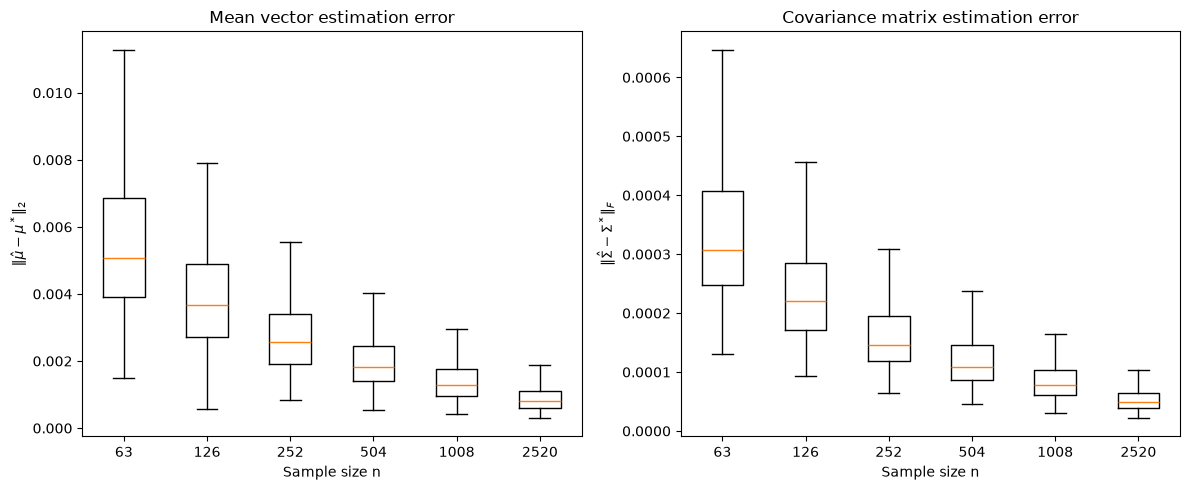

Empirical convergence rate: mu error ~ n^-0.503, Sigma error ~ n^-0.498


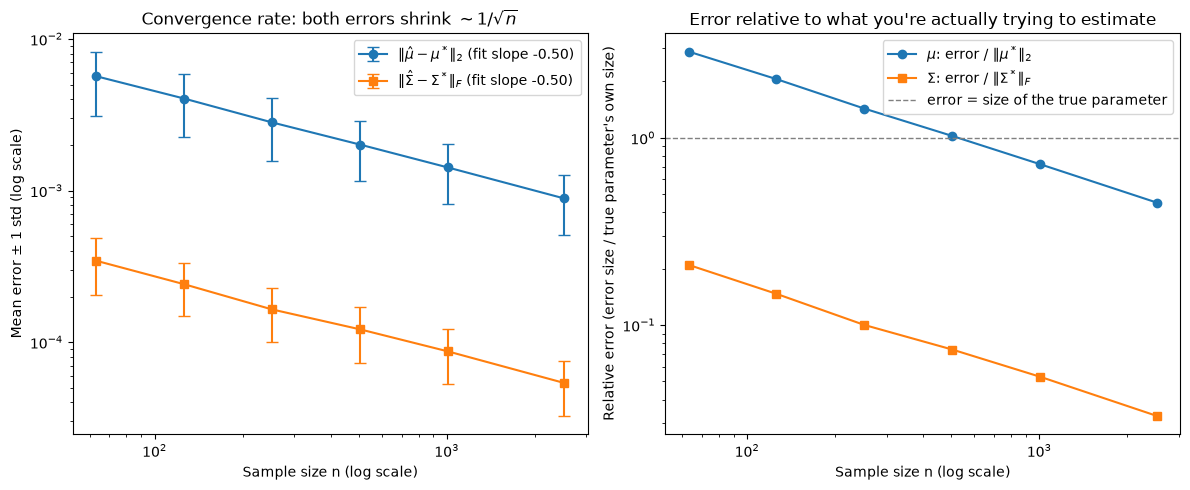

,mu_mean,mu_std,sigma_mean,sigma_std,mu_rel_error,sigma_rel_error
n,,,,,,
63,0.005678,0.002576,0.000344,0.000138,2.885851,0.209539
126,0.004045,0.001799,0.000241,0.000093,2.055934,0.146702
252,0.002815,0.001252,0.000164,0.000065,1.430712,0.100026
504,0.002010,0.000862,0.000122,0.000049,1.021748,0.073926
1008,0.001420,0.000601,0.000087,0.000034,0.721581,0.052882
2520,0.000887,0.000381,0.000054,0.000021,0.450887,0.032735


In [3]:
mu_star = returns.mean()
Sigma_star = returns.cov()

N_GRID = [63, 126, 252, 504, 1008, 2520]
N_REPS = 1000

mu_errors = {n: [] for n in N_GRID}
Sigma_errors = {n: [] for n in N_GRID}

mu_star_vec = mu_star.values
Sigma_star_mat = Sigma_star.values

for n in N_GRID:
    for _ in range(N_REPS):
        sample = np.random.multivariate_normal(mu_star_vec, Sigma_star_mat, size=n)
        mu_hat = sample.mean(axis=0)
        Sigma_hat = np.cov(sample, rowvar=False)

        mu_errors[n].append(np.linalg.norm(mu_hat - mu_star_vec))
        Sigma_errors[n].append(np.linalg.norm(Sigma_hat - Sigma_star_mat, ord="fro"))

mu_error_df = pd.DataFrame(mu_errors)
Sigma_error_df = pd.DataFrame(Sigma_errors)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot([mu_error_df[n] for n in N_GRID], tick_labels=N_GRID, showfliers=False)
axes[0].set_xlabel("Sample size n")
axes[0].set_ylabel(r"$\|\hat{\mu} - \mu^*\|_2$")
axes[0].set_title("Mean vector estimation error")

axes[1].boxplot([Sigma_error_df[n] for n in N_GRID], tick_labels=N_GRID, showfliers=False)
axes[1].set_xlabel("Sample size n")
axes[1].set_ylabel(r"$\|\hat{\Sigma} - \Sigma^*\|_F$")
axes[1].set_title("Covariance matrix estimation error")
plt.tight_layout()
plt.show()

# --- convergence rate + relative-error summary ---
summary_df = pd.DataFrame({
    "n": N_GRID,
    "mu_mean": [mu_error_df[n].mean() for n in N_GRID],
    "mu_std": [mu_error_df[n].std() for n in N_GRID],
    "sigma_mean": [Sigma_error_df[n].mean() for n in N_GRID],
    "sigma_std": [Sigma_error_df[n].std() for n in N_GRID],
}).set_index("n")

mu_star_norm = np.linalg.norm(mu_star_vec)
Sigma_star_norm = np.linalg.norm(Sigma_star_mat, ord="fro")
summary_df["mu_rel_error"] = summary_df["mu_mean"] / mu_star_norm
summary_df["sigma_rel_error"] = summary_df["sigma_mean"] / Sigma_star_norm

log_n = np.log(N_GRID)
mu_slope, _ = np.polyfit(log_n, np.log(summary_df["mu_mean"]), 1)
sigma_slope, _ = np.polyfit(log_n, np.log(summary_df["sigma_mean"]), 1)
print(f"Empirical convergence rate: mu error ~ n^{mu_slope:.3f}, Sigma error ~ n^{sigma_slope:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].errorbar(N_GRID, summary_df["mu_mean"], yerr=summary_df["mu_std"], marker="o", capsize=4,
                  label=rf"$\|\hat{{\mu}}-\mu^*\|_2$ (fit slope {mu_slope:.2f})")
axes[0].errorbar(N_GRID, summary_df["sigma_mean"], yerr=summary_df["sigma_std"], marker="s", capsize=4,
                  label=rf"$\|\hat{{\Sigma}}-\Sigma^*\|_F$ (fit slope {sigma_slope:.2f})")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Sample size n (log scale)")
axes[0].set_ylabel("Mean error ± 1 std (log scale)")
axes[0].set_title(r"Convergence rate: both errors shrink $\sim 1/\sqrt{n}$")
axes[0].legend()

axes[1].plot(N_GRID, summary_df["mu_rel_error"], marker="o", label=r"$\mu$: error / $\|\mu^*\|_2$")
axes[1].plot(N_GRID, summary_df["sigma_rel_error"], marker="s", label=r"$\Sigma$: error / $\|\Sigma^*\|_F$")
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="error = size of the true parameter")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Sample size n (log scale)")
axes[1].set_ylabel("Relative error (error size / true parameter's own size)")
axes[1].set_title("Error relative to what you're actually trying to estimate")
axes[1].legend()
plt.tight_layout()
plt.show()

summary_df

The boxplots show raw error ($\ell_2$ for $\mu$, Frobenius for $\Sigma$) across 1000 replicates per $n$. The error-bar plot shows the same means with std bars on a log-log scale, plus a fitted slope for the convergence rate. The relative-error plot divides each error by the size of the true parameter, which is what actually determines whether an estimate is usable.

**Convergence rate.** Both errors shrink at almost the same rate: slope $-0.50$ for $\mu$ and $-0.50$ for $\Sigma$ (seed = 1), matching the standard $1/\sqrt{n}$ rate for sample averages. So the difference between them below comes from signal size, not speed.

**$\mu$.** Relative error stays above 1 (error bigger than $\mu^*$ itself) through $n=504$, and only drops below 1 at $n=1008$ (0.72). Even at $n=2520$ (10 years of data) it's still around 0.45. $\mu$ is hard to pin down at any realistic sample size, which is part of why 2.2 uses CAPM instead of the plug-in sample mean.

**$\Sigma$.** Relative error is about 10% at $n=252$, 5% at $n=1008$, and 3% at $n=2520$. Around $n=1008$ is a reasonable point to treat $\hat\Sigma$ as usable.

### Section 2.2 - Model Uncertainty on Real Data

CAPM per-asset alpha / beta / idiosyncratic variance:


,alpha,beta,resid_var
XLC,-0.000098,0.986154,0.000052
XLY,-0.000203,1.112127,0.000046
XLP,0.000072,0.525970,0.000057
XLE,0.000030,0.944929,0.000269
XLF,-0.000092,1.006226,0.000066
XLV,0.000040,0.687451,0.000052
XLI,-0.000030,0.973293,0.000042
XLB,-0.000135,0.944547,0.000061
XLRE,-0.000113,0.807759,0.000093
XLK,0.000170,1.287975,0.000043



Mean vector comparison:


,sample (annualized %),CAPM (annualized %),abs diff
XLF,13.627384,13.627384,1.598721e-14
XLI,14.669414,14.669414,1.421085e-14
XLK,24.694814,24.694814,1.421085e-14
XLY,12.508134,12.508134,1.243450e-14
XLE,15.746986,15.746986,1.243450e-14
XLRE,9.956825,9.956825,1.243450e-14
XLC,13.165490,13.165490,1.065814e-14
XLV,11.901986,11.901986,8.881784e-15
XLP,10.145684,10.145684,7.105427e-15
XLB,11.575566,11.575566,7.105427e-15


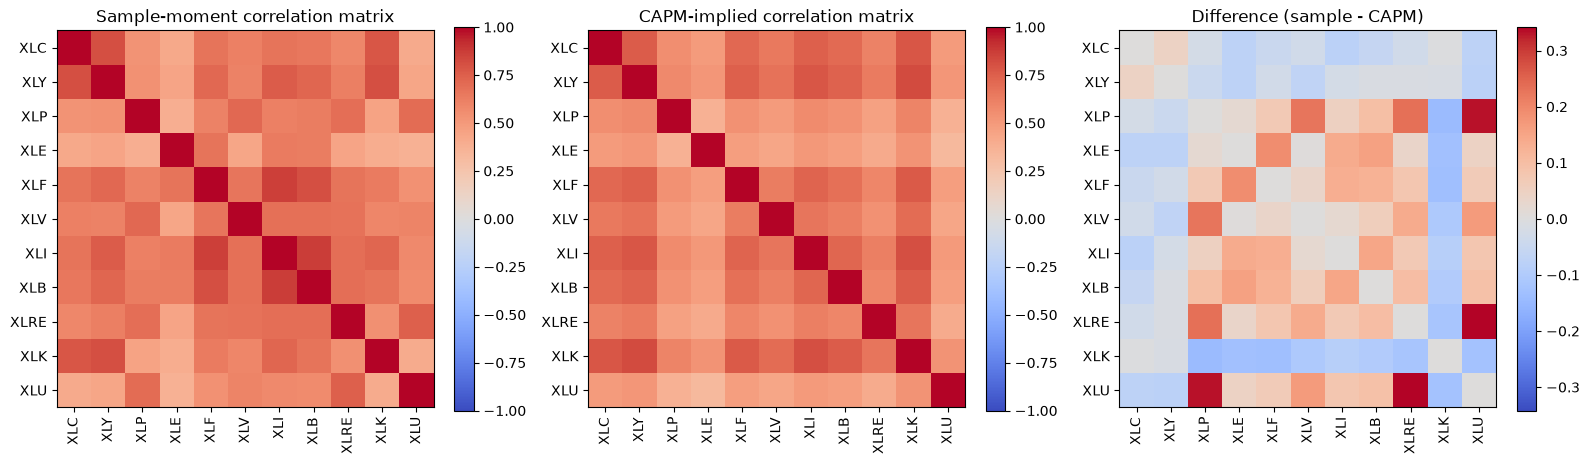


Largest |sample corr - CAPM corr| off-diagonal pairs:


Ticker  Ticker
XLRE    XLU       0.341871
XLU     XLP       0.332487
XLRE    XLP       0.234403
XLV     XLP       0.225060
XLE     XLF       0.191589
XLU     XLV       0.165954
XLB     XLE       0.155762
        XLI       0.147915
XLK     XLP      -0.144195
XLRE    XLV       0.138307
Name: corr diff (sample - CAPM), dtype: float64

In [4]:
# --- Method 1: sample moments (just the 11 sector ETFs; SPY excluded since it's the CAPM factor, not a target) ---
mu_sample = returns[TICKERS].mean()
Sigma_sample = returns[TICKERS].cov()
Corr_sample = returns[TICKERS].corr()

# --- Method 2: single-factor CAPM via matrix multiplication (module 2) ---
X = np.column_stack([np.ones(len(returns)), returns[MARKET].values])  # (n, 2): [1, r_SPY]
Y = returns[TICKERS].values                                            # (n, 11)

B_hat = np.linalg.lstsq(X, Y, rcond=None)[0]   # (2, 11): row 0 = alpha_i, row 1 = beta_i
alpha_hat, beta_hat = B_hat[0], B_hat[1]

resids = Y - X @ B_hat
resid_var = resids.var(axis=0, ddof=1)          # idiosyncratic variance per asset (CAPM assumes these are uncorrelated across assets)

r_mkt_mean = returns[MARKET].mean()
r_mkt_var = returns[MARKET].var(ddof=1)

# Law of total expectation: E[mu_i] = alpha_i + beta_i * E[r_market]
mu_capm = pd.Series(alpha_hat + beta_hat * r_mkt_mean, index=TICKERS)

# Law of total covariance: Sigma = beta beta^T * var(r_market) + diag(idiosyncratic variances)
Sigma_capm = pd.DataFrame(
    np.outer(beta_hat, beta_hat) * r_mkt_var + np.diag(resid_var),
    index=TICKERS, columns=TICKERS,
)
Corr_capm = Sigma_capm / np.sqrt(np.outer(np.diag(Sigma_capm), np.diag(Sigma_capm)))

capm_params = pd.DataFrame({"alpha": alpha_hat, "beta": beta_hat, "resid_var": resid_var}, index=TICKERS)
print("CAPM per-asset alpha / beta / idiosyncratic variance:")
display(capm_params)

# --- Side-by-side mean vectors (annualized, x252, for readability) ---
mu_compare = pd.DataFrame({
    "sample (annualized %)": mu_sample * 252 * 100,
    "CAPM (annualized %)": mu_capm * 252 * 100,
})
mu_compare["abs diff"] = (mu_compare["sample (annualized %)"] - mu_compare["CAPM (annualized %)"]).abs()
print("\nMean vector comparison:")
display(mu_compare.sort_values("abs diff", ascending=False))

# --- Covariance / correlation comparison plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].imshow(Corr_sample, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_xticks(range(len(TICKERS))); axes[0].set_xticklabels(TICKERS, rotation=90)
axes[0].set_yticks(range(len(TICKERS))); axes[0].set_yticklabels(TICKERS)
axes[0].set_title("Sample-moment correlation matrix")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(Corr_capm, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_xticks(range(len(TICKERS))); axes[1].set_xticklabels(TICKERS, rotation=90)
axes[1].set_yticks(range(len(TICKERS))); axes[1].set_yticklabels(TICKERS)
axes[1].set_title("CAPM-implied correlation matrix")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

corr_diff = Corr_sample - Corr_capm
lim = np.abs(corr_diff.values).max()
im2 = axes[2].imshow(corr_diff, vmin=-lim, vmax=lim, cmap="coolwarm")
axes[2].set_xticks(range(len(TICKERS))); axes[2].set_xticklabels(TICKERS, rotation=90)
axes[2].set_yticks(range(len(TICKERS))); axes[2].set_yticklabels(TICKERS)
axes[2].set_title("Difference (sample - CAPM)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

# --- Which off-diagonal pairs differ the most? ---
diff_stacked = corr_diff.where(~np.eye(len(TICKERS), dtype=bool)).stack()
top_diff_pairs = diff_stacked.abs().sort_values(ascending=False).drop_duplicates().head(10)
print("\nLargest |sample corr - CAPM corr| off-diagonal pairs:")
display(diff_stacked.loc[top_diff_pairs.index].rename("corr diff (sample - CAPM)"))

**Mean vector.** Sample and CAPM means match almost exactly (differences around $10^{-14}$, floating-point noise). This is expected: OLS with an intercept always fits through the average, so $\hat\alpha_i + \hat\beta_i\bar r_{\text{SPY}}$ reduces to the sample mean itself. CAPM's effect here is entirely in $\Sigma$, not $\mu$.

**Why correlation instead of covariance.** Correlation is on a fixed $[-1,1]$ scale, so differences between pairs are directly comparable regardless of each asset's own volatility.

**Covariance / correlation.** The two methods disagree a lot. The ten largest correlation gaps between the sample and CAPM matrices range from about 0.14 to 0.34, which is large relative to the full possible range of 2.

**Sensitivity.** Since $\mathbf{w}^*$ depends on $\hat\Sigma^{-1}$, a correlation gap of this size can noticeably change the optimal weights. The choice of estimation method matters here, not just sampling noise within one method.

**Where the gap comes from.** Nine of the ten largest gaps have sample correlation higher than CAPM's -- those sector pairs move together more than a shared SPY beta explains. One pair (XLP-XLK) goes the other way, with CAPM implying a higher correlation than what actually happened.

### Section 2.3 - Bootstrap and Rolling Window

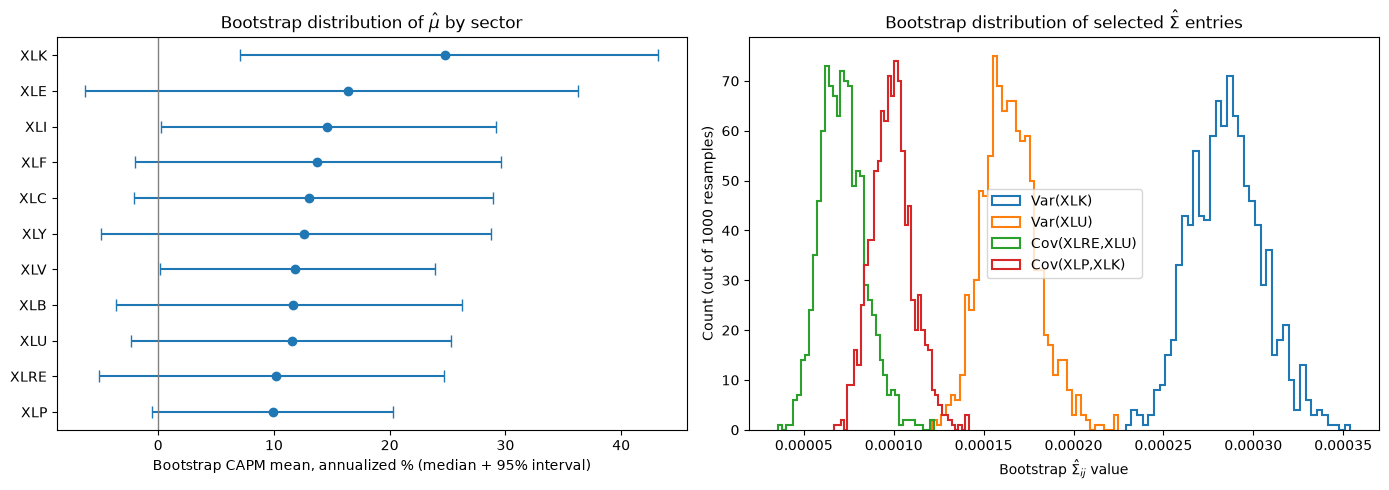

In [5]:
def fit_capm(ret_df):
    """Single-factor CAPM fit (as in 2.2): returns (mu_hat, Sigma_hat) as plain numpy arrays."""
    X = np.column_stack([np.ones(len(ret_df)), ret_df[MARKET].values])
    Y = ret_df[TICKERS].values
    B = np.linalg.lstsq(X, Y, rcond=None)[0]
    alpha, beta = B[0], B[1]
    resid_var = (Y - X @ B).var(axis=0, ddof=1)
    r_mkt_mean = ret_df[MARKET].mean()
    r_mkt_var = ret_df[MARKET].var(ddof=1)
    mu = alpha + beta * r_mkt_mean
    Sigma = np.outer(beta, beta) * r_mkt_var + np.diag(resid_var)
    return mu, Sigma


# --- Bootstrap: resample days with replacement, refit CAPM each time ---
N_BOOT = 1000
n_obs = len(returns)
rng = np.random.default_rng(RNG_SEED)

boot_mu = np.zeros((N_BOOT, len(TICKERS)))
boot_Sigma = np.zeros((N_BOOT, len(TICKERS), len(TICKERS)))

for b in range(N_BOOT):
    idx = rng.integers(0, n_obs, size=n_obs)
    resampled = returns.iloc[idx]
    boot_mu[b], boot_Sigma[b] = fit_capm(resampled)

# Forest plot: bootstrap mean (annualized %) and 95% percentile interval per sector
mu_annual = boot_mu * 252 * 100
mu_median = np.median(mu_annual, axis=0)
mu_lo = np.percentile(mu_annual, 2.5, axis=0)
mu_hi = np.percentile(mu_annual, 97.5, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = np.argsort(mu_median)
axes[0].errorbar(mu_median[order], np.arange(len(TICKERS)),
                  xerr=[mu_median[order] - mu_lo[order], mu_hi[order] - mu_median[order]],
                  fmt="o", capsize=4)
axes[0].set_yticks(np.arange(len(TICKERS)))
axes[0].set_yticklabels(np.array(TICKERS)[order])
axes[0].axvline(0, color="gray", linewidth=1)
axes[0].set_xlabel("Bootstrap CAPM mean, annualized % (median + 95% interval)")
axes[0].set_title("Bootstrap distribution of $\\hat{\\mu}$ by sector")

# Distribution of a few Sigma_hat entries: two variances, two covariance pairs
tickers_idx = {t: i for i, t in enumerate(TICKERS)}
pairs_to_show = [("XLK", "XLK"), ("XLU", "XLU"), ("XLRE", "XLU"), ("XLP", "XLK")]
for (a, c) in pairs_to_show:
    ia, ic = tickers_idx[a], tickers_idx[c]
    label = f"Var({a})" if a == c else f"Cov({a},{c})"
    axes[1].hist(boot_Sigma[:, ia, ic], bins=40, histtype="step", linewidth=1.5, label=label)
axes[1].set_xlabel("Bootstrap $\\hat{\\Sigma}_{ij}$ value")
axes[1].set_ylabel("Count (out of 1000 resamples)")
axes[1].set_title("Bootstrap distribution of selected $\\hat{\\Sigma}$ entries")
axes[1].legend()

plt.tight_layout()
plt.show()

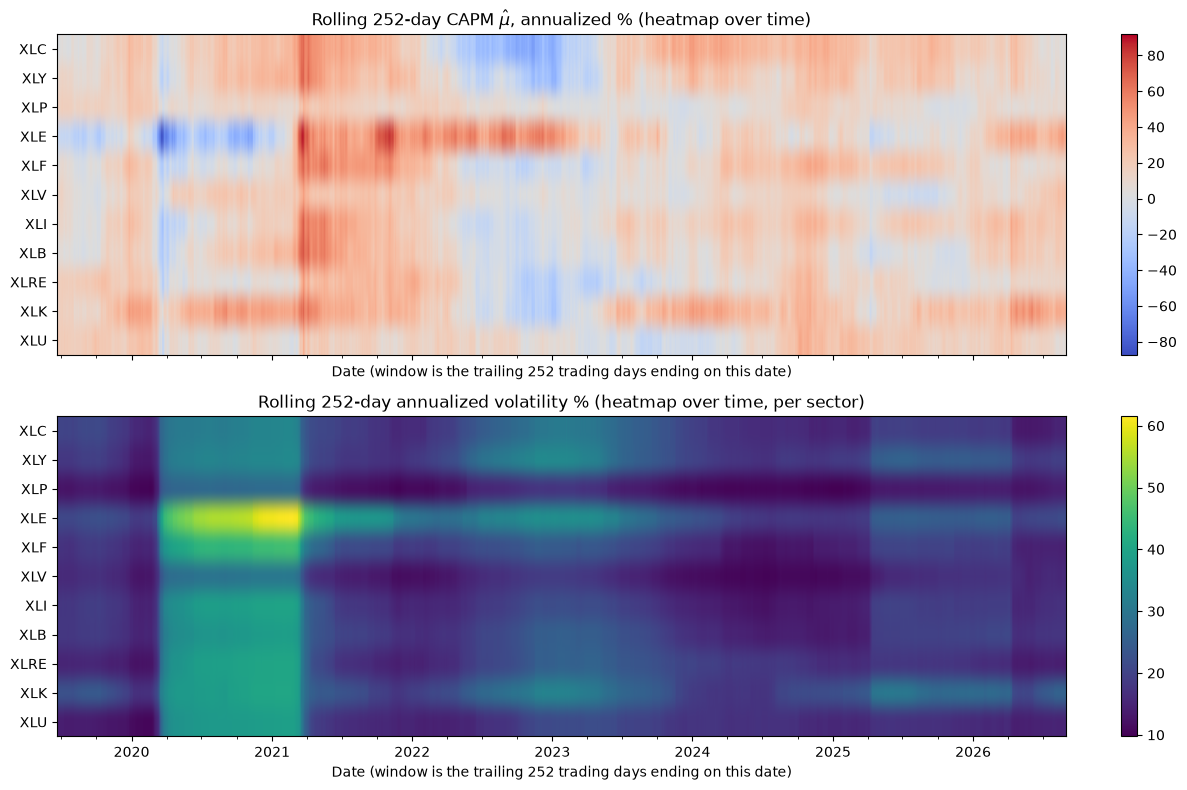

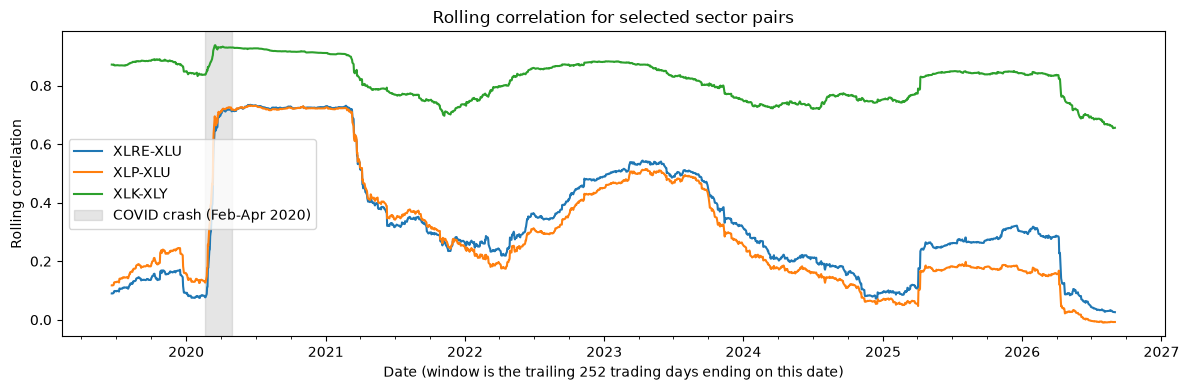

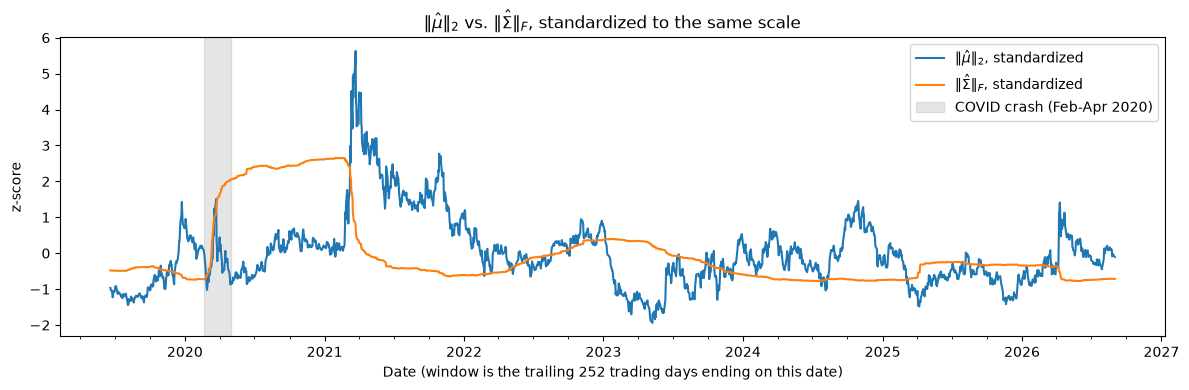

Average |z-score| over time -- ||mu_hat||: 0.72  ||Sigma_hat||_F: 0.72
Largest |z-score| reached -- ||mu_hat||: 5.63  ||Sigma_hat||_F: 2.65
Correlation between the two raw series over time: 0.036


In [6]:
import matplotlib.dates as mdates

# --- Rolling window: refit CAPM on each trailing 252-day window, in time order ---
WINDOW = 252
roll_dates = returns.index[WINDOW - 1:]
n_windows = len(roll_dates)

roll_mu = np.zeros((n_windows, len(TICKERS)))
roll_vol = np.zeros((n_windows, len(TICKERS)))  # annualized volatility (sqrt of diag Sigma) -- per-asset only
roll_mu_norm = np.zeros(n_windows)              # ||mu_hat||_2, daily units -- mu_hat as a whole vector
roll_Sigma_fro = np.zeros(n_windows)            # ||Sigma_hat||_F, daily units -- Sigma_hat as a whole matrix

pairs_to_track = [("XLRE", "XLU"), ("XLP", "XLU"), ("XLK", "XLY")]
roll_corr = {pair: np.zeros(n_windows) for pair in pairs_to_track}

for i in range(n_windows):
    window_df = returns.iloc[i:i + WINDOW]
    mu_t, Sigma_t = fit_capm(window_df)
    roll_mu[i] = mu_t
    roll_vol[i] = np.sqrt(np.diag(Sigma_t)) * np.sqrt(252)
    roll_mu_norm[i] = np.linalg.norm(mu_t)
    roll_Sigma_fro[i] = np.linalg.norm(Sigma_t, ord="fro")

    for (a, c) in pairs_to_track:
        ia, ic = tickers_idx[a], tickers_idx[c]
        roll_corr[(a, c)][i] = Sigma_t[ia, ic] / np.sqrt(Sigma_t[ia, ia] * Sigma_t[ic, ic])

roll_mu_annual = roll_mu * 252 * 100
roll_vol_pct = roll_vol * 100
date_nums = mdates.date2num(roll_dates)
covid_start, covid_end = pd.Timestamp("2020-02-20"), pd.Timestamp("2020-04-30")


def format_date_axis(ax):
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator([1, 4, 7, 10]))
    ax.set_xlabel("Date (window is the trailing 252 trading days ending on this date)")


# --- Heatmaps: mu and volatility, per sector (both have colorbars, so their axes compress the same way) ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

im0 = axes[0].imshow(roll_mu_annual.T, aspect="auto", cmap="coolwarm",
                      extent=[date_nums[0], date_nums[-1], len(TICKERS), 0])
axes[0].set_yticks(np.arange(len(TICKERS)) + 0.5)
axes[0].set_yticklabels(TICKERS)
axes[0].set_title(r"Rolling 252-day CAPM $\hat{\mu}$, annualized % (heatmap over time)")
plt.colorbar(im0, ax=axes[0], fraction=0.03)

im1 = axes[1].imshow(roll_vol_pct.T, aspect="auto", cmap="viridis",
                      extent=[date_nums[0], date_nums[-1], len(TICKERS), 0])
axes[1].set_yticks(np.arange(len(TICKERS)) + 0.5)
axes[1].set_yticklabels(TICKERS)
axes[1].set_title(r"Rolling 252-day annualized volatility % (heatmap over time, per sector)")
plt.colorbar(im1, ax=axes[1], fraction=0.03)

for ax in axes:
    format_date_axis(ax)

plt.tight_layout()
plt.show()

# --- Correlation: its own figure, no colorbar, so its axis isn't compressed relative to the heatmaps ---
fig, ax = plt.subplots(figsize=(12, 4))
for pair, series in roll_corr.items():
    ax.plot(roll_dates, series, label=f"{pair[0]}-{pair[1]}")
ax.axvspan(covid_start, covid_end, color="gray", alpha=0.2, label="COVID crash (Feb-Apr 2020)")
ax.set_ylabel("Rolling correlation")
ax.set_title("Rolling correlation for selected sector pairs")
ax.legend()
format_date_axis(ax)

plt.tight_layout()
plt.show()

# --- The actual comparison we care about: mu_hat as a whole vector vs Sigma_hat as a whole matrix ---
# Per-sector volatility above only looks at the diagonal of Sigma_hat. The Frobenius norm folds in
# every variance AND covariance entry, which is what the optimizer (Sigma_hat^-1 mu_hat) actually
# uses. ||mu_hat|| is in return units and ||Sigma_hat||_F is in return-units-squared, so the two
# aren't comparable in raw form -- standardizing each to its own z-score removes that mismatch and
# is unaffected by any constant scaling (e.g. annualizing), so we just use daily units directly.
mu_norm_s = pd.Series(roll_mu_norm, index=roll_dates)
sigma_fro_s = pd.Series(roll_Sigma_fro, index=roll_dates)
mu_norm_z = (mu_norm_s - mu_norm_s.mean()) / mu_norm_s.std()
sigma_fro_z = (sigma_fro_s - sigma_fro_s.mean()) / sigma_fro_s.std()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(roll_dates, mu_norm_z, label=r"$\|\hat{\mu}\|_2$, standardized")
ax.plot(roll_dates, sigma_fro_z, label=r"$\|\hat{\Sigma}\|_F$, standardized")
ax.axvspan(covid_start, covid_end, color="gray", alpha=0.2, label="COVID crash (Feb-Apr 2020)")
ax.set_ylabel("z-score")
ax.set_title(r"$\|\hat{\mu}\|_2$ vs. $\|\hat{\Sigma}\|_F$, standardized to the same scale")
ax.legend()
format_date_axis(ax)
plt.tight_layout()
plt.show()

print("Average |z-score| over time -- ||mu_hat||:", round(mu_norm_z.abs().mean(), 2),
      " ||Sigma_hat||_F:", round(sigma_fro_z.abs().mean(), 2))
print("Largest |z-score| reached -- ||mu_hat||:", round(mu_norm_z.abs().max(), 2),
      " ||Sigma_hat||_F:", round(sigma_fro_z.abs().max(), 2))
print("Correlation between the two raw series over time:", round(mu_norm_s.corr(sigma_fro_s), 3))

**Bootstrap.** $\hat\mu$ is volatile: 8 of 11 sectors have a 95% interval that includes zero. $\hat\Sigma$ is much more tightly distributed around its point estimate. This matches 2.1: $\mu$ is the harder parameter to pin down.

**Rolling window.** $\hat\mu$ is noisy over time and flips sign often in the top heatmap (blue to red). The per-sector volatility heatmap only looks at the diagonal of $\hat\Sigma$, so it's not the full picture -- the optimizer uses all of $\hat\Sigma$, variances and covariances together. Using $\|\hat\Sigma\|_F$ (the whole matrix) instead of just volatility gives a fair comparison to $\|\hat\mu\|_2$ (the whole mean vector), both standardized to the same scale: average variability is close (0.72 for $\mu$, also 0.72 for $\Sigma$), but $\mu$ reaches a much larger extreme (max z of 5.6 vs. 2.7 for $\Sigma$), and the two series are barely correlated with each other (0.04) -- they don't necessarily spike at the same time.

Overall $\Sigma$ is still the steadier estimate: it stays in a more predictable range and doesn't flip sign, while $\mu$ swings further and occasionally moves to an extreme with no clear counterpart in $\Sigma$.

**Regimes.** Crashes raise correlation and volatility across sectors -- COVID (Feb-Apr 2020) is the clearest example, and similar tariff-driven selloffs do the same. Because the window is 252 trading days, one crash keeps distorting the rolling estimate for about a year afterward, which is why volatility and correlation stay elevated well past the event itself and only fall once the crash days roll out of the window. $\|\hat\Sigma\|_F$ peaks in a window dated January 2021, for the same reason.

There's also a separate low-$\mu$ period in the middle of the sample, from mid-2022 to early 2023, bottoming around October 2022 -- distinct from the COVID trough and consistent with the 2022 rate-hike selloff.

### Section 2.4 - Dimension vs. Sample Size

Real beta: mean=0.898, std=0.224
Real idiosyncratic variance: mean=0.000081, range=[0.000042, 0.000269]
k=12 matches 2.1 real estimates exactly: True


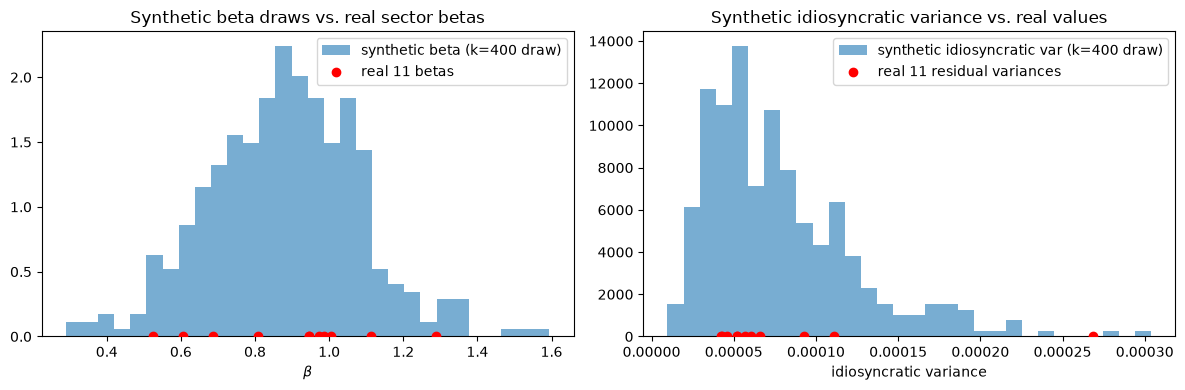

In [7]:
# --- Ground truth mu*(k), Sigma*(k) for arbitrary k ---
# k <= 12: subset of the real full-sample estimates from 2.1 (mu_star, Sigma_star -- 12 columns,
#          TICKERS + SPY, so we have exactly 12 real assets to draw from).
# k > 12:  no more real assets exist, so we build a synthetic k-asset universe using the same
#          one-factor structure as the 2.2 CAPM fit: Sigma*(k) = diag(D) + beta beta^T * sigma_m^2.
#          beta and D are drawn from distributions fit to the 11 real CAPM betas / residual
#          variances from 2.2, so the synthetic universe still reflects real, estimated market
#          behavior rather than made-up numbers.

beta_fit_mean, beta_fit_std = beta_hat.mean(), beta_hat.std(ddof=1)
log_resid_var = np.log(resid_var)
logvar_fit_mean, logvar_fit_std = log_resid_var.mean(), log_resid_var.std(ddof=1)  # log-normal: residual variances must stay positive, and the real 11 are right-skewed

K_GRID = [5, 12, 50, 150, 252, 500, 1000]
rng24 = np.random.default_rng(RNG_SEED)


def ground_truth(k):
    """Return (mu_star_k, Sigma_star_k), the (synthetic, for k>12) true parameters for a k-asset universe."""
    if k <= 12:
        mu_k = mu_star_vec[:k]
        Sigma_k = Sigma_star_mat[:k, :k]
    else:
        beta_k = rng24.normal(beta_fit_mean, beta_fit_std, size=k)
        D_k = np.exp(rng24.normal(logvar_fit_mean, logvar_fit_std, size=k))
        Sigma_k = np.outer(beta_k, beta_k) * r_mkt_var + np.diag(D_k)
        mu_k = beta_k * r_mkt_mean  # zero synthetic alpha: no built-in mispricing for the made-up assets
    return mu_k, Sigma_k


# --- Sanity checks: does the construction actually look right? ---
print(f"Real beta: mean={beta_fit_mean:.3f}, std={beta_fit_std:.3f}")
print(f"Real idiosyncratic variance: mean={resid_var.mean():.6f}, range=[{resid_var.min():.6f}, {resid_var.max():.6f}]")

# k <= 12 should reproduce the 2.1 real estimates exactly
mu_12, Sigma_12 = ground_truth(12)
print("k=12 matches 2.1 real estimates exactly:",
      np.allclose(mu_12, mu_star_vec) and np.allclose(Sigma_12, Sigma_star_mat))

# For a large synthetic k, compare the drawn beta/D distribution to the real 11 values
rng_plot = np.random.default_rng(RNG_SEED)
beta_400 = rng_plot.normal(beta_fit_mean, beta_fit_std, size=400)
D_400 = np.exp(rng_plot.normal(logvar_fit_mean, logvar_fit_std, size=400))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(beta_400, bins=30, density=True, alpha=0.6, label="synthetic beta (k=400 draw)")
axes[0].scatter(beta_hat, np.zeros_like(beta_hat), color="red", zorder=5, label="real 11 betas")
axes[0].set_title("Synthetic beta draws vs. real sector betas")
axes[0].set_xlabel(r"$\beta$")
axes[0].legend()

axes[1].hist(D_400, bins=30, density=True, alpha=0.6, label="synthetic idiosyncratic var (k=400 draw)")
axes[1].scatter(resid_var, np.zeros_like(resid_var), color="red", zorder=5, label="real 11 residual variances")
axes[1].set_title("Synthetic idiosyncratic variance vs. real values")
axes[1].set_xlabel(r"idiosyncratic variance")
axes[1].legend()

plt.tight_layout()
plt.show()

**How $\boldsymbol\mu^*(k)$ and $\boldsymbol\Sigma^*(k)$ are built.** For $k \le 12$ we just reuse the real full-sample estimates from 2.1 ($\mu^*$, $\Sigma^*$ over all 12 tickers, sector ETFs plus SPY) and take the first $k$ columns/rows. For $k>12$ there's no real 13th asset, so we build a synthetic one instead, using the same one-factor structure as the 2.2 CAPM fit: $\Sigma^*(k) = \boldsymbol\beta\boldsymbol\beta^\top\sigma_m^2 + \mathbf{D}$. $\sigma_m^2$ is the real SPY variance from 2.2. $\boldsymbol\beta$ is drawn from a normal distribution fit to the 11 real CAPM betas (mean 0.898, std 0.224). $\mathbf{D}$'s entries are drawn from a log-normal fit to the 11 real residual variances -- log-normal because variances have to stay positive and the real 11 are right-skewed (mostly 4-11e-5, with XLE at 2.7e-4). $\mu^*(k)$ for the synthetic assets is $\boldsymbol\beta \cdot \bar r_{\text{SPY}}$, i.e. zero alpha -- we don't have a real alpha to draw from for a made-up asset, and zero alpha is the standard "fairly priced" CAPM assumption anyway.

,cond_med,cond_lo,cond_hi,mineig_med,mineig_frac_nonpos,wnorm_med,wnorm_lo,wnorm_hi,grosslev_med
k,,,,,,,,,
5,2.057050e+01,1.918239e+01,2.262732e+01,3.631954e-05,0.0,3.065013e+00,2.398483e+00,3.947027e+00,5.641663e+00
12,1.595680e+03,1.470716e+03,1.708536e+03,1.008700e-06,0.0,1.086799e+01,7.973955e+00,1.746693e+01,2.695428e+01
50,4.497965e+02,4.166459e+02,4.916562e+02,1.375526e-05,0.0,1.620337e+01,1.480027e+01,1.763762e+01,9.011561e+01
150,5.731936e+03,5.327812e+03,6.171915e+03,3.058516e-06,0.0,7.881847e+01,6.886753e+01,8.633416e+01,7.453525e+02
252,3.230628e+12,3.068406e+12,3.421031e+12,-1.354132e-20,1.0,9.621068e+14,3.946688e+14,2.182090e+15,1.162562e+16
500,6.309987e+12,5.900107e+12,6.669067e+12,-6.988944e-18,1.0,3.892366e+16,2.085969e+16,7.474147e+16,6.793924e+17
1000,1.247751e+13,1.184950e+13,1.330839e+13,-2.339995e-17,1.0,5.131124e+16,3.079513e+16,1.099825e+17,1.263442e+18


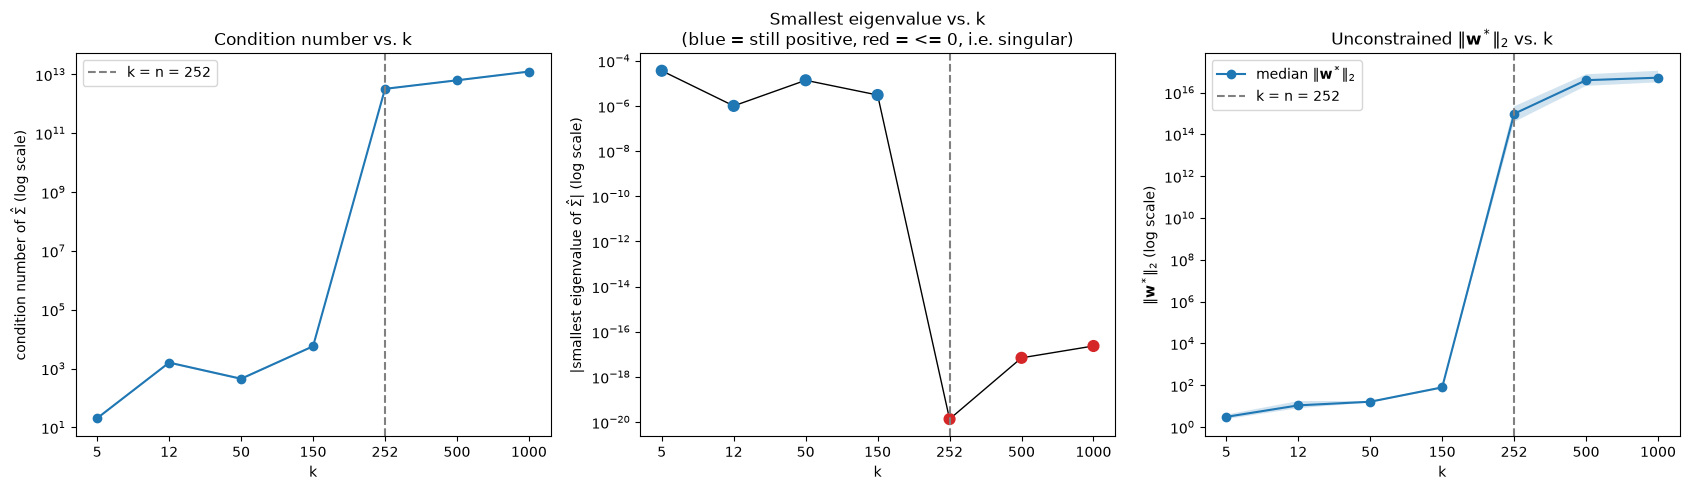

In [8]:
# --- Simulate at each k: draw N_REPS_24 samples of size n=252 from N(mu*(k), Sigma*(k)),
#     compute Sigma_hat each time, and track condition number, smallest eigenvalue, and ||w*|| ---
N_REPS_24 = 200
N_SIM = 252          # sample size fixed for the whole subsection, per the prompt
GAMMA_24 = 5.0        # fixed risk aversion, just so w* has one consistent scale across k

results_24 = {}
for k in K_GRID:
    mu_k, Sigma_k = ground_truth(k)
    L = np.linalg.cholesky(Sigma_k)  # fixed per k; reused so we don't refactor Sigma_k every replicate

    cond_list, mineig_list, wnorm_list, gl_list = [], [], [], []
    for _ in range(N_REPS_24):
        Z = np.random.standard_normal((N_SIM, k))
        sample = mu_k + Z @ L.T
        mu_hat = sample.mean(axis=0)
        Sigma_hat = np.cov(sample, rowvar=False)

        eigvals = np.linalg.eigvalsh(Sigma_hat)
        min_eig = eigvals.min()
        cond_list.append(eigvals.max() / max(min_eig, 1e-14))
        mineig_list.append(min_eig)

        # w* = (1/gamma) Sigma_hat^-1 mu_hat -- solved directly (no regularization), so it shows
        # exactly what a naive implementation would do with a near-singular or singular Sigma_hat
        w = np.linalg.solve(Sigma_hat, mu_hat) / GAMMA_24
        wnorm_list.append(np.linalg.norm(w))
        gl_list.append(np.abs(w).sum())

    results_24[k] = dict(cond=np.array(cond_list), min_eig=np.array(mineig_list),
                          w_norm=np.array(wnorm_list), gross_lev=np.array(gl_list))

# median + interquartile band per k, for plotting
summary_24 = pd.DataFrame({
    "k": K_GRID,
    "cond_med": [np.median(results_24[k]["cond"]) for k in K_GRID],
    "cond_lo": [np.percentile(results_24[k]["cond"], 25) for k in K_GRID],
    "cond_hi": [np.percentile(results_24[k]["cond"], 75) for k in K_GRID],
    "mineig_med": [np.median(results_24[k]["min_eig"]) for k in K_GRID],
    "mineig_frac_nonpos": [(results_24[k]["min_eig"] <= 1e-10).mean() for k in K_GRID],
    "wnorm_med": [np.median(results_24[k]["w_norm"]) for k in K_GRID],
    "wnorm_lo": [np.percentile(results_24[k]["w_norm"], 25) for k in K_GRID],
    "wnorm_hi": [np.percentile(results_24[k]["w_norm"], 75) for k in K_GRID],
    "grosslev_med": [np.median(results_24[k]["gross_lev"]) for k in K_GRID],
}).set_index("k")
display(summary_24)

# categorical x positions (evenly spaced), labeled with the actual k values -- K_GRID isn't
# evenly spaced (5 to 1000), so a true linear or log axis would squeeze the small-k points together
x_pos = np.arange(len(K_GRID))
k_idx = K_GRID.index(N_SIM)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(x_pos, summary_24["cond_med"], marker="o")
axes[0].fill_between(x_pos, summary_24["cond_lo"], summary_24["cond_hi"], alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("k")
axes[0].set_ylabel(r"condition number of $\hat{\Sigma}$ (log scale)")
axes[0].set_title("Condition number vs. k")
axes[0].axvline(k_idx, color="gray", linestyle="--", label=f"k = n = {N_SIM}")
axes[0].legend()

# smallest eigenvalue: plot |value|, marker color shows whether it's still positive (valid) or
# has gone numerically zero/negative (Sigma_hat is no longer really invertible)
colors = ["tab:blue" if summary_24.loc[k, "mineig_frac_nonpos"] < 0.5 else "tab:red" for k in K_GRID]
axes[1].plot(x_pos, summary_24["mineig_med"].abs(), color="black", linewidth=1, zorder=1)
axes[1].scatter(x_pos, summary_24["mineig_med"].abs(), c=colors, zorder=2, s=60)
axes[1].set_yscale("log")
axes[1].set_xlabel("k")
axes[1].set_ylabel(r"$|$smallest eigenvalue of $\hat{\Sigma}|$ (log scale)")
axes[1].set_title("Smallest eigenvalue vs. k\n(blue = still positive, red = <= 0, i.e. singular)")
axes[1].axvline(k_idx, color="gray", linestyle="--")

axes[2].plot(x_pos, summary_24["wnorm_med"], marker="o", label=r"median $\|\mathbf{w}^*\|_2$")
axes[2].fill_between(x_pos, summary_24["wnorm_lo"], summary_24["wnorm_hi"], alpha=0.2)
axes[2].set_yscale("log")
axes[2].set_xlabel("k")
axes[2].set_ylabel(r"$\|\mathbf{w}^*\|_2$ (log scale)")
axes[2].set_title(r"Unconstrained $\|\mathbf{w}^*\|_2$ vs. k")
axes[2].axvline(k_idx, color="gray", linestyle="--", label=f"k = n = {N_SIM}")
axes[2].legend()

for ax in axes:
    ax.set_xticks(x_pos)
    ax.set_xticklabels(K_GRID)

plt.tight_layout()
plt.show()

All three quantities are flat and modest while $k < n$, then jump by many orders of magnitude right at $k=n=252$: condition number goes from about 5,857 at $k=150$ to $3.3\times10^{12}$ at $k=252$; the smallest eigenvalue flips from a tiny positive number ($3\times10^{-6}$) to a tiny negative one ($-2.4\times10^{-21}$); and $\|\mathbf{w}^*\|_2$ goes from about 79 to $1.3\times10^{15}$. By $k=500$ and $k=1000$, every single replicate has a non-positive smallest eigenvalue.

The jump happens exactly at $k=n$, not somewhere after it, because estimating the sample mean uses up one degree of freedom -- a sample covariance from $n$ rows can have rank at most $n-1$. So once $k \ge n$, $\hat\Sigma$ is mathematically guaranteed to be singular, not just poorly estimated.

This connects directly to $\mathbf{w}^* \propto \hat{\Sigma}^{-1}\hat{\mu}$: inverting a matrix means dividing by its eigenvalues, so a matrix with a near-zero eigenvalue produces a near-infinite result in that direction once inverted. `np.linalg.solve` doesn't error out here -- floating-point rounding keeps the determinant technically nonzero -- so it just silently returns an enormous, meaningless weight vector instead of failing loudly. That's arguably worse than a crash.

The important part is that this is entirely an estimation problem, not a property of the market. 2.4a already confirmed $\Sigma^*(k)$ itself -- the true parameter -- has a strictly positive smallest eigenvalue at every $k$ we tested, including $k=1000$. $n=252$ days simply isn't enough data to pin down a $1000\times1000$ covariance matrix; the true structure is fine, the estimate of it is not. This is why Section 3.5's constrained weights, and shrinkage estimators like Ledoit-Wolf in practice, exist: rather than inverting $\hat\Sigma$ as-is, they push it toward something better-conditioned before inverting, trading a bit of bias for a covariance matrix that's actually safe to divide by.

## Section 3 - How Uncertainty in Parameters Propagates to Weights

**Base estimates, fixed for all of Section 3.** Every sub-part below uses one pair $\hat{\boldsymbol\mu}$, $\hat{\boldsymbol\Sigma}$: the single-factor CAPM fit from 2.3 (`fit_capm`), run on the first 60% of the sample (1,235 of 2,059 days, ending 2023-05-16). That 60/40 split is the one Section 4 uses, so the reference portfolio here never sees test data. CAPM rather than sample moments because 2.2 showed the two produce the same $\hat{\boldsymbol\mu}$ to floating-point precision -- the only real choice is $\hat{\boldsymbol\Sigma}$, and the one-factor version is the better-conditioned of the two.

**Which $\mathbf{w}^*$.** `mpt_weights` is module 2's closed form: it maximizes $U(\mathbf{w}) = \mathbf{w}^\intercal\boldsymbol\mu - \tfrac{\gamma}{2}\mathbf{w}^\intercal\boldsymbol\Sigma\mathbf{w}$ subject to the budget constraint $\mathbf{1}^\intercal\mathbf{w} = 1$. "Unconstrained" in this section means what the prompt means by it -- free to short and to lever -- with the fully-invested budget constraint still in force. Section 3.4 also reports the no-budget-constraint solution $\hat{\boldsymbol\Sigma}^{-1}\hat{\boldsymbol\mu}/\gamma$, which is the one place the distinction changes the answer.

**Units.** $\hat{\boldsymbol\mu}$ and $\hat{\boldsymbol\Sigma}$ stay in daily units. Annualizing both by 252 leaves $\mathbf{w}^*$ *exactly* unchanged -- the $\lambda$ solved from the budget constraint absorbs the common factor -- so the $\gamma$ grid means the same thing under either convention. Returns and volatilities are annualized only for reporting ($\times 252$ for means, $\times\sqrt{252}$ for volatilities).

**What counts as "reasonable."** Throughout Section 3, gross exposure $\sum_i |w_i|$ is the yardstick, with $\sum_i|w_i| \le 2$ (2-to-1 gross, the prompt's own leverage example) as the threshold. A fully-invested long-only portfolio sits at exactly 1.

In [9]:
from scipy.optimize import minimize

# --- Base estimates: the 2.3 CAPM fit, on the TRAINING window only ---
# Section 4 splits the data 60/40. Section 3's reference mu_hat / Sigma_hat is fit on that same
# 60% training window, so the base portfolio never sees test data. mu_base and Sigma_base are
# fixed here and every sub-part of Section 3 reuses them unchanged.
TRAIN_FRAC = 0.60
n_train = int(len(returns) * TRAIN_FRAC)
returns_train = returns.iloc[:n_train]
mu_base, Sigma_base = fit_capm(returns_train)

K = len(TICKERS)   # 11 sector ETFs; SPY is the CAPM factor, not a holding
GAMMA_BASE = 5.0   # fixed risk aversion for 3.2-3.5 (same value as GAMMA_24 in 2.4)
GROSS_OK = 2.0     # "reasonable" = gross exposure sum_i |w_i| <= 2, i.e. at most 2-to-1 gross


def mpt_weights(mu, Sigma, gamma, s=1.0):
    """Closed-form MPT weights (module 2): maximize w'mu - (gamma/2) w'Sigma w subject to 1'w = s."""
    Sinv = np.linalg.inv(Sigma)
    ones = np.ones(len(mu))
    q1 = ones @ Sinv @ mu
    q2 = ones @ Sinv @ ones
    lam = (q1 - gamma * s) / q2
    return Sinv @ (mu - lam * ones) / gamma


def weight_path(grid, weight_fn):
    """w* at each value of a scalar parameter: a (len(grid), 11) frame indexed by that parameter."""
    return pd.DataFrame([weight_fn(p) for p in grid], index=grid, columns=TICKERS)


def path_diagnostics(W_df):
    """Gross exposure, largest long, and largest short at each point along a weight path."""
    return pd.DataFrame({
        "gross_leverage": W_df.abs().sum(axis=1),
        "max_long": W_df.max(axis=1),
        "max_short": W_df.min(axis=1),
    }, index=W_df.index)


def plot_weight_path(W_df, xlabel, title, logx=False, symlog_w=False, log_gross=False):
    """Left: every sector's weight along the path. Right: gross exposure vs. the GROSS_OK line."""
    diag = path_diagnostics(W_df)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for t in TICKERS:
        axes[0].plot(W_df.index, W_df[t], label=t)
    axes[0].axhline(0, color="gray", linewidth=1)
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel(r"Weight $w_i^*$")
    axes[0].set_title(title)
    axes[0].legend(ncol=2, fontsize=8)

    axes[1].plot(diag.index, diag["gross_leverage"], color="black",
                 label=r"gross exposure $\sum_i |w_i|$")
    axes[1].axhline(GROSS_OK, color="red", linestyle="--", label=f"'reasonable' threshold ({GROSS_OK:.0f}x gross)")
    axes[1].axhline(1.0, color="gray", linestyle=":", label="long-only, fully invested (= 1)")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel(r"$\sum_i |w_i|$")
    axes[1].set_title("Gross exposure along the same path")
    axes[1].legend(fontsize=8)

    if logx:
        axes[0].set_xscale("log")
        axes[1].set_xscale("log")
    if symlog_w:
        axes[0].set_yscale("symlog", linthresh=1)   # weights span +-80, but the action is near 0
    if log_gross:
        axes[1].set_yscale("log")

    plt.tight_layout()
    plt.show()
    return diag


# --- The gamma -> infinity limit and the "speculative tilt", both reused throughout Section 3 ---
Sinv_base = np.linalg.inv(Sigma_base)
ones_k = np.ones(len(TICKERS))
w_minvar = Sinv_base @ ones_k / (ones_k @ Sinv_base @ ones_k)          # min-variance portfolio
z_tilt = Sinv_base @ mu_base - (ones_k @ Sinv_base @ mu_base) / (ones_k @ Sinv_base @ ones_k) * Sinv_base @ ones_k

w_base = mpt_weights(mu_base, Sigma_base, GAMMA_BASE)
base_table = pd.DataFrame({
    "mu_base (annualized %)": mu_base * 252 * 100,
    "volatility (annualized %)": np.sqrt(np.diag(Sigma_base)) * np.sqrt(252) * 100,
    f"base w* (gamma = {GAMMA_BASE:g})": w_base,
    "min-variance w (gamma -> inf)": w_minvar,
}, index=TICKERS)

print(f"Training window: {returns_train.index.min().date()} to {returns_train.index.max().date()} "
      f"({len(returns_train)} of {len(returns)} days = {TRAIN_FRAC:.0%})")
print(f"Base w* gross exposure: {np.abs(w_base).sum():.2f}   min-variance gross exposure: {np.abs(w_minvar).sum():.2f}")
display(base_table.round(3))

Training window: 2018-06-20 to 2023-05-16 (1235 of 2059 days = 60%)
Base w* gross exposure: 5.31   min-variance gross exposure: 2.27


,mu_base (annualized %),volatility (annualized %),base w* (gamma = 5),min-variance w (gamma -> inf)
XLC,7.735,25.068,-0.626,0.008
XLY,9.995,25.775,-0.565,-0.110
XLP,12.278,17.346,0.925,0.666
XLE,12.467,36.967,-0.020,-0.017
XLF,8.819,27.045,-0.449,-0.057
XLV,12.379,19.270,0.750,0.526
XLI,10.522,24.044,-0.237,0.051
XLB,10.785,24.599,-0.137,0.048
XLRE,9.038,24.595,-0.121,0.113
XLK,20.515,28.160,1.223,-0.452


### Section 3.1 - Sensitivity to Gamma

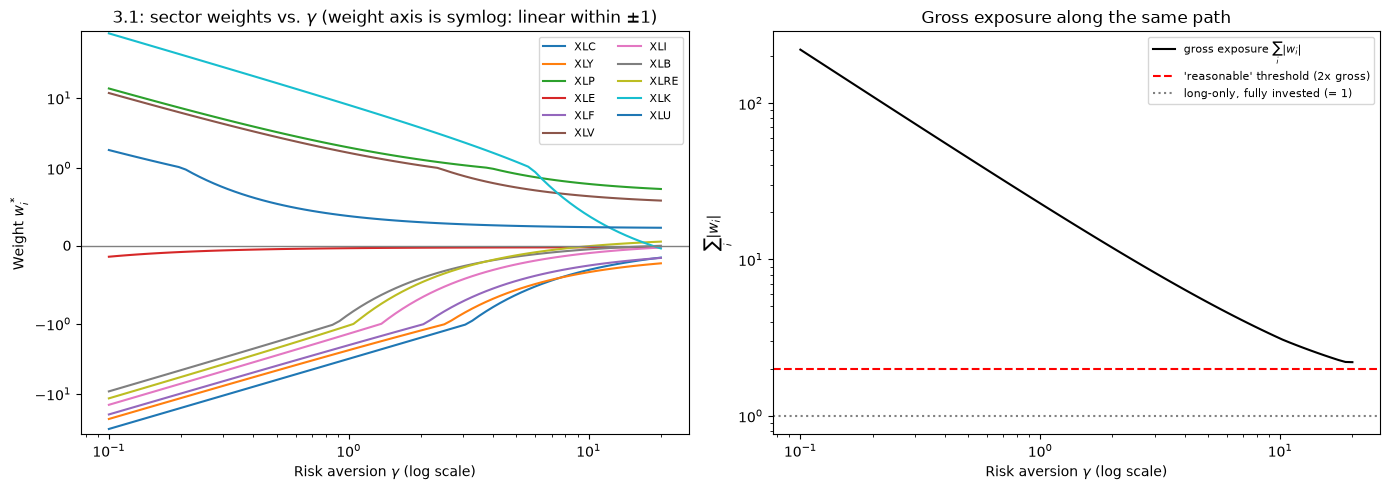

Full weight vector at selected gammas (columns sum to 1 by construction):


,gamma=0.1,gamma=0.5,gamma=1,gamma=2,gamma=5,gamma=10,gamma=20,gamma -> inf
XLC,-31.691,-6.332,-3.162,-1.577,-0.626,-0.309,-0.150,0.008
XLY,-22.819,-4.652,-2.381,-1.246,-0.565,-0.338,-0.224,-0.110
XLP,13.624,3.257,1.961,1.314,0.925,0.795,0.730,0.666
XLE,-0.139,-0.042,-0.030,-0.023,-0.020,-0.019,-0.018,-0.017
XLF,-19.666,-3.978,-2.018,-1.037,-0.449,-0.253,-0.155,-0.057
XLV,11.736,2.768,1.647,1.086,0.750,0.638,0.582,0.526
XLI,-14.331,-2.826,-1.387,-0.668,-0.237,-0.093,-0.021,0.051
XLB,-9.216,-1.805,-0.879,-0.415,-0.137,-0.045,0.001,0.048
XLRE,-11.593,-2.228,-1.057,-0.472,-0.121,-0.004,0.055,0.113
XLK,83.291,16.297,7.923,3.735,1.223,0.386,-0.033,-0.452


,gross_leverage,max_long,max_short
0.1,219.91,83.29,-31.69
0.5,44.72,16.30,-6.33
1.0,22.83,7.92,-3.16
2.0,11.88,3.74,-1.58
5.0,5.31,1.22,-0.63
10.0,3.12,0.80,-0.34
20.0,2.20,0.73,-0.22



Smallest gross exposure over gamma in [0.1, 10000]: 2.19 at gamma = 27.8
Gross exposure of the gamma -> infinity (minimum-variance) portfolio: 2.27
Gamma values in [0.1, 10000] that reach gross <= 2: 0 of 400


In [10]:
# --- 3.1: sweep gamma on a log grid, holding mu_base and Sigma_base fixed ---
GAMMA_GRID = np.logspace(np.log10(0.1), np.log10(20), 80)
W_gamma = weight_path(GAMMA_GRID, lambda g: mpt_weights(mu_base, Sigma_base, g))

diag_gamma = plot_weight_path(
    W_gamma, r"Risk aversion $\gamma$ (log scale)",
    r"3.1: sector weights vs. $\gamma$ (weight axis is symlog: linear within $\pm 1$)",
    logx=True, symlog_w=True, log_gross=True,
)

# Full weight vector at a handful of gammas, plus the gamma -> infinity limit
GAMMA_SHOW = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
gamma_table = weight_path(GAMMA_SHOW, lambda g: mpt_weights(mu_base, Sigma_base, g)).T
gamma_table.columns = [f"gamma={g:g}" for g in GAMMA_SHOW]
gamma_table["gamma -> inf"] = w_minvar
print("Full weight vector at selected gammas (columns sum to 1 by construction):")
display(gamma_table.round(3))
display(path_diagnostics(weight_path(GAMMA_SHOW, lambda g: mpt_weights(mu_base, Sigma_base, g))).round(2))

# Does gross exposure ever fall under GROSS_OK? Push gamma far past the grid to find the floor.
gamma_far = np.logspace(np.log10(0.1), 4, 400)
gross_far = np.abs(np.array([mpt_weights(mu_base, Sigma_base, g) for g in gamma_far])).sum(axis=1)
print(f"\nSmallest gross exposure over gamma in [0.1, 10000]: {gross_far.min():.2f} at gamma = {gamma_far[gross_far.argmin()]:.1f}")
print(f"Gross exposure of the gamma -> infinity (minimum-variance) portfolio: {np.abs(w_minvar).sum():.2f}")
print(f"Gamma values in [0.1, 10000] that reach gross <= {GROSS_OK:g}: {(gross_far <= GROSS_OK).sum()} of {len(gamma_far)}")

**The extreme cases.** At $\gamma = 0.1$ the optimizer wants $+83\times$ XLK financed by $-32\times$ XLC and $-23\times$ XLY, for gross exposure of 220. Every weight is hyperbolic in $\gamma$: $\mathbf{w}^*(\gamma) = \mathbf{w}_{\text{minvar}} + \mathbf{z}/\gamma$, so the left panel is a family of $1/\gamma$ curves, and the whole path collapses onto a single line in weight space.

**The composition flips, it doesn't just shrink.** XLK is the largest long at low $\gamma$ ($+83$ at $\gamma = 0.1$, $+1.22$ at $\gamma = 5$) and becomes a *short* at $\gamma = 20$ ($-0.03$), reaching $-0.45$ in the limit. XLK has both the highest estimated mean (20.5% annualized) and the highest beta (1.29 in 2.2). Low $\gamma$ chases the mean, high $\gamma$ flees the variance, and the sign of the position tells you which term won.

**Where it becomes reasonable: nowhere in the requested range.** Gross exposure falls monotonically across the grid but only reaches 2.20 at $\gamma = 20$, still above the threshold. Pushing $\gamma$ to $10^4$ doesn't fix it: gross exposure bottoms at 2.19 near $\gamma \approx 28$ and then *rises* back to 2.27, because the $\gamma \to \infty$ limit is the minimum-variance portfolio, which itself shorts XLK 45% and XLY 11%. So there is a floor of roughly $2.2\times$ gross that no amount of risk aversion removes.

That floor is the point. $\gamma$ controls the size of the speculative tilt $\mathbf{z}/\gamma$, not the min-variance anchor it is added to, so raising $\gamma$ can never produce a long-only portfolio here. Getting one requires actually constraining the problem, which is Section 3.5.

### Section 3.2 - Sensitivity to Mu

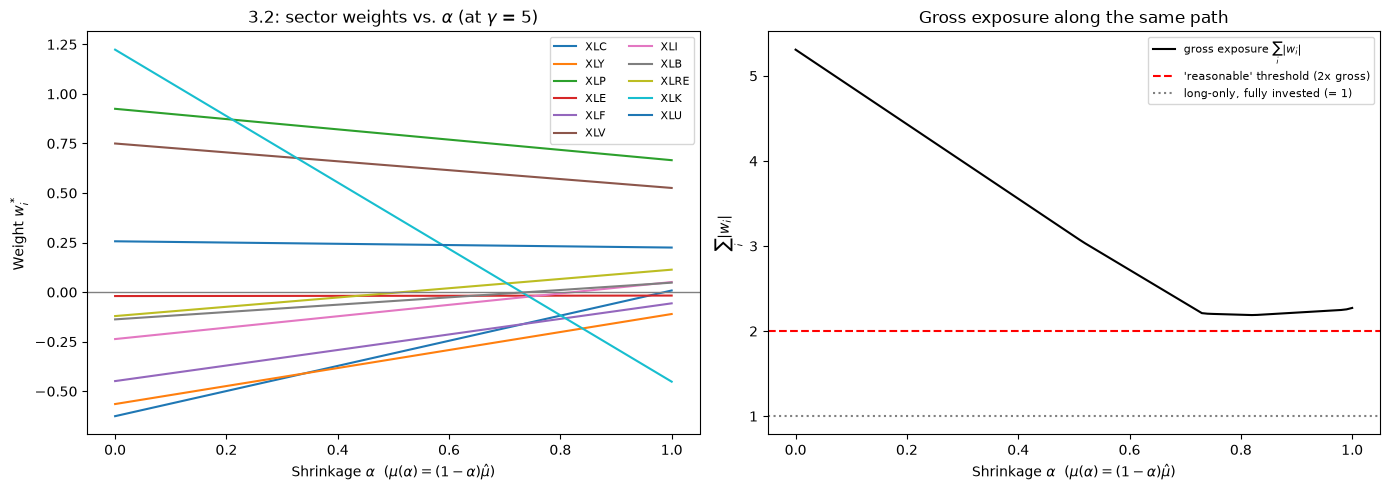

Full weight vector along the shrinkage path:


,alpha=0,alpha=0.25,alpha=0.5,alpha=0.75,alpha=0.9,alpha=1
XLC,-0.626,-0.467,-0.309,-0.150,-0.055,0.008
XLY,-0.565,-0.451,-0.338,-0.224,-0.156,-0.110
XLP,0.925,0.860,0.795,0.730,0.691,0.666
XLE,-0.020,-0.019,-0.019,-0.018,-0.018,-0.017
XLF,-0.449,-0.351,-0.253,-0.155,-0.096,-0.057
XLV,0.750,0.694,0.638,0.582,0.548,0.526
XLI,-0.237,-0.165,-0.093,-0.021,0.022,0.051
XLB,-0.137,-0.091,-0.045,0.001,0.029,0.048
XLRE,-0.121,-0.062,-0.004,0.055,0.090,0.113
XLK,1.223,0.804,0.386,-0.033,-0.284,-0.452


,gross_leverage,max_long,max_short
0.00,5.31,1.22,-0.63
0.25,4.21,0.86,-0.47
0.50,3.12,0.80,-0.34
0.75,2.20,0.73,-0.22
0.90,2.22,0.69,-0.28
1.00,2.27,0.67,-0.45



w(alpha) is exactly affine in alpha, ending at the min-variance portfolio: True
Shrinking mu by (1-alpha) == raising gamma to gamma/(1-alpha) (checked at alpha=0.8): True
Alphas reaching gross <= 2: none
Minimum gross exposure along the path: 2.19 at alpha = 0.82


In [11]:
# --- 3.2: shrink the estimated means toward zero, holding Sigma_base and gamma fixed ---
ALPHA_GRID = np.linspace(0.0, 1.0, 101)
W_alpha = weight_path(ALPHA_GRID, lambda a: mpt_weights((1 - a) * mu_base, Sigma_base, GAMMA_BASE))

diag_alpha = plot_weight_path(
    W_alpha, r"Shrinkage $\alpha$  ($\mu(\alpha) = (1-\alpha)\hat{\mu}$)",
    rf"3.2: sector weights vs. $\alpha$ (at $\gamma$ = {GAMMA_BASE:g})",
)

ALPHA_SHOW = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]
alpha_table = weight_path(ALPHA_SHOW, lambda a: mpt_weights((1 - a) * mu_base, Sigma_base, GAMMA_BASE)).T
alpha_table.columns = [f"alpha={a:g}" for a in ALPHA_SHOW]
print("Full weight vector along the shrinkage path:")
display(alpha_table.round(3))
display(path_diagnostics(weight_path(ALPHA_SHOW, lambda a: mpt_weights((1 - a) * mu_base, Sigma_base, GAMMA_BASE))).round(2))

# Two structural facts worth checking rather than asserting:
# (i) mu enters w* linearly and the budget constraint is affine, so the whole path is a straight
#     line between the base portfolio and the minimum-variance portfolio.
affine_ok = np.allclose(W_alpha.values,
                        np.outer(1 - ALPHA_GRID, W_alpha.iloc[0].values) + np.outer(ALPHA_GRID, w_minvar))
# (ii) shrinking mu by (1-alpha) is algebraically identical to raising gamma to gamma / (1-alpha).
a_chk = 0.8
gamma_equiv_ok = np.allclose(mpt_weights((1 - a_chk) * mu_base, Sigma_base, GAMMA_BASE),
                             mpt_weights(mu_base, Sigma_base, GAMMA_BASE / (1 - a_chk)))
print(f"\nw(alpha) is exactly affine in alpha, ending at the min-variance portfolio: {affine_ok}")
print(f"Shrinking mu by (1-alpha) == raising gamma to gamma/(1-alpha) (checked at alpha={a_chk}): {gamma_equiv_ok}")

first_ok = diag_alpha.index[diag_alpha["gross_leverage"] <= GROSS_OK]
print(f"Alphas reaching gross <= {GROSS_OK:g}: {'none' if len(first_ok) == 0 else f'from alpha = {first_ok.min():.2f}'}")
print(f"Minimum gross exposure along the path: {diag_alpha['gross_leverage'].min():.2f} "
      f"at alpha = {diag_alpha['gross_leverage'].idxmin():.2f}")

**The path is a straight line.** $\boldsymbol\mu$ enters $\mathbf{w}^*$ linearly and the budget constraint is affine, so the whole shrinkage path is the segment $\mathbf{w}^*(\alpha) = (1-\alpha)\,\mathbf{w}^*(0) + \alpha\,\mathbf{w}_{\text{minvar}}$ -- checked exactly in the cell above. At $\alpha = 1$ the means are gone and only $\hat{\boldsymbol\Sigma}$ is left, which is the minimum-variance portfolio by definition.

**It is the same dial as 3.1.** Shrinking $\boldsymbol\mu$ by $(1-\alpha)$ is algebraically identical to raising risk aversion to $\gamma/(1-\alpha)$, verified at $\alpha = 0.8$. From the weights alone you cannot separate "my return estimates are noisy" from "I am a cautious investor" -- they enter the solution through the same scalar. That is worth knowing before reading anything into a $\gamma$ someone picked.

**Where the weights settle down.** Gross exposure runs 5.31 at $\alpha = 0$, 3.12 at $\alpha = 0.5$, and 2.20 at $\alpha = 0.75$, where the largest short has shrunk from $-63\%$ (XLC) to $-22\%$. Past that there is nothing left to gain: the minimum is 2.19 at $\alpha = 0.82$, then it edges back to 2.27 at $\alpha = 1$ -- the same $\approx 2.2$ floor found in 3.1, since it is a property of $\hat{\boldsymbol\Sigma}$ and survives deleting $\hat{\boldsymbol\mu}$ entirely. Call $\alpha \approx 0.75$ the well-behaved point, with the caveat that it never crosses 2.

**Throwing away three-quarters of $\hat{\boldsymbol\mu}$ is not as reckless as it sounds.** 2.3's bootstrap put 8 of 11 sector 95% intervals across zero, and 2.1 found the relative error in $\hat{\boldsymbol\mu}$ still above 1 at $n = 504$. Heavy shrinkage is roughly what that evidence supports, and it happens to be where the weights stop misbehaving.

### Section 3.3 - Sensitivity to Correlations

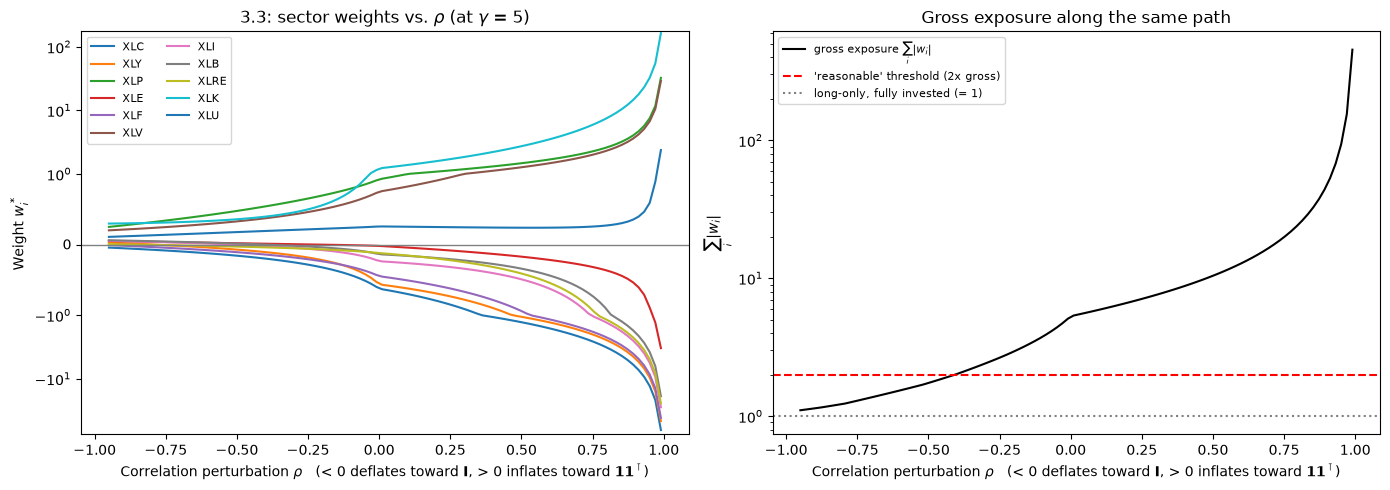

Variances preserved at every rho: True   Smallest eigenvalue positive at every rho: True

Full weight vector at selected rho:


,rho=-0.9,rho=-0.5,rho=0,rho=0.5,rho=0.9,rho=0.99
XLC,-0.05,-0.16,-0.63,-1.29,-6.44,-64.04
XLY,0.02,-0.07,-0.56,-1.06,-4.80,-46.40
XLP,0.27,0.48,0.92,1.47,4.26,32.44
XLE,0.05,0.02,-0.02,-0.17,-0.56,-3.30
XLF,-0.02,-0.11,-0.45,-0.94,-4.33,-41.33
XLV,0.21,0.33,0.75,1.27,3.80,29.01
XLI,0.05,-0.00,-0.24,-0.49,-2.72,-28.07
XLB,0.06,0.01,-0.14,-0.34,-1.87,-18.86
XLRE,0.00,-0.03,-0.12,-0.41,-2.42,-24.42
XLK,0.30,0.36,1.22,2.73,15.71,163.59


,gross_leverage,max_long,max_short,avg off-diag corr,condition number
-0.90,1.14,0.30,-0.05,0.07,4.93
-0.50,1.74,0.48,-0.16,0.34,13.49
0.00,5.31,1.22,-0.63,0.68,53.95
0.50,10.42,2.73,-1.29,0.84,128.64
0.90,47.28,15.71,-6.44,0.97,729.42
0.99,453.83,163.59,-64.04,1.00,7490.59


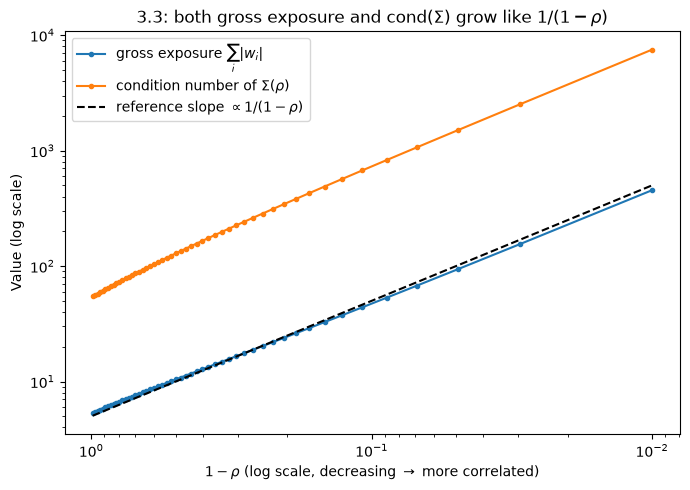


Literal (1-rho)C + rho*11'/k at rho=0.5: diagonal = 0.545 (a correlation matrix needs 1.000), mean off-diagonal = 0.385 vs. 0.679 at rho = 0 -- it deflates, not inflates.


In [12]:
# --- 3.3: Sigma = D C D, then perturb only C ---
D_base = np.sqrt(np.diag(Sigma_base))                 # diag(sigma_1, ..., sigma_k)
C_base = Sigma_base / np.outer(D_base, D_base)        # correlation matrix
ONES_MAT = np.ones((K, K))
OFFDIAG = ~np.eye(K, dtype=bool)


def corr_perturbed(rho):
    """C(rho): blend the estimated correlation matrix toward all-ones (rho > 0, inflate) or
    toward the identity (rho < 0, deflate). Both targets are themselves correlation matrices,
    so the diagonal stays exactly 1 -- the variances in Sigma(rho) = D C(rho) D are untouched --
    and a convex combination of PSD matrices is PSD, so positive definiteness survives for |rho| < 1."""
    target = ONES_MAT if rho >= 0 else np.eye(K)
    return (1 - abs(rho)) * C_base + abs(rho) * target


def sigma_perturbed(rho):
    return np.outer(D_base, D_base) * corr_perturbed(rho)


RHO_GRID = np.linspace(-0.95, 0.99, 100)
W_rho = weight_path(RHO_GRID, lambda r: mpt_weights(mu_base, sigma_perturbed(r), GAMMA_BASE))

diag_rho = plot_weight_path(
    W_rho, r"Correlation perturbation $\rho$   (< 0 deflates toward $\mathbf{I}$, > 0 inflates toward $\mathbf{1}\mathbf{1}^\intercal$)",
    rf"3.3: sector weights vs. $\rho$ (at $\gamma$ = {GAMMA_BASE:g})",
    symlog_w=True, log_gross=True,
)

# The perturbation has to leave variances alone and stay positive definite -- check, don't assume.
rho_checks = pd.DataFrame({
    "avg off-diag corr": [corr_perturbed(r)[OFFDIAG].mean() for r in RHO_GRID],
    "variances unchanged": [np.allclose(np.diag(sigma_perturbed(r)), np.diag(Sigma_base)) for r in RHO_GRID],
    "min eigenvalue": [np.linalg.eigvalsh(sigma_perturbed(r)).min() for r in RHO_GRID],
    "condition number": [np.linalg.cond(sigma_perturbed(r)) for r in RHO_GRID],
}, index=RHO_GRID)
print(f"Variances preserved at every rho: {rho_checks['variances unchanged'].all()}   "
      f"Smallest eigenvalue positive at every rho: {(rho_checks['min eigenvalue'] > 0).all()}")

RHO_SHOW = [-0.9, -0.5, 0.0, 0.5, 0.9, 0.99]
rho_table = weight_path(RHO_SHOW, lambda r: mpt_weights(mu_base, sigma_perturbed(r), GAMMA_BASE)).T
rho_table.columns = [f"rho={r:g}" for r in RHO_SHOW]
print("\nFull weight vector at selected rho:")
display(rho_table.round(2))
summary_rho = path_diagnostics(weight_path(RHO_SHOW, lambda r: mpt_weights(mu_base, sigma_perturbed(r), GAMMA_BASE)))
summary_rho["avg off-diag corr"] = [corr_perturbed(r)[OFFDIAG].mean() for r in RHO_SHOW]
summary_rho["condition number"] = [np.linalg.cond(sigma_perturbed(r)) for r in RHO_SHOW]
display(summary_rho.round(2))

# Why it blows up: as rho -> 1 the k-1 "spread" eigenvalues of Sigma(rho) shrink like (1 - rho),
# so Sigma(rho)^-1 -- and the weights, which live mostly in those directions -- grow like 1/(1 - rho).
fig, ax = plt.subplots(figsize=(7, 5))
pos = RHO_GRID > 0
ax.plot(1 - RHO_GRID[pos], diag_rho["gross_leverage"].values[pos], marker=".", label=r"gross exposure $\sum_i|w_i|$")
ax.plot(1 - RHO_GRID[pos], rho_checks["condition number"].values[pos], marker=".",
        label=r"condition number of $\Sigma(\rho)$")
ax.plot(1 - RHO_GRID[pos], 5.0 / (1 - RHO_GRID[pos]), color="black", linestyle="--",
        label=r"reference slope $\propto 1/(1-\rho)$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel(r"$1 - \rho$ (log scale, decreasing $\rightarrow$ more correlated)")
ax.set_ylabel("Value (log scale)")
ax.set_title(r"3.3: both gross exposure and $\mathrm{cond}(\Sigma)$ grow like $1/(1-\rho)$")
ax.legend()
plt.tight_layout(); plt.show()

# The prompt's literal C(rho) = (1-rho)C + rho*11'/k does not keep a unit diagonal, so it would
# quietly rescale the variances -- the one thing 3.3 is supposed to hold fixed.
lit_half = 0.5 * C_base + 0.5 * ONES_MAT / K
print(f"\nLiteral (1-rho)C + rho*11'/k at rho=0.5: diagonal = {lit_half[0, 0]:.3f} (a correlation matrix needs 1.000), "
      f"mean off-diagonal = {lit_half[OFFDIAG].mean():.3f} vs. {C_base[OFFDIAG].mean():.3f} at rho = 0 -- it deflates, not inflates.")

**A note on the perturbation used.** The prompt's literal $\mathbf{C}(\rho) = (1-\rho)\mathbf{C} + \rho\mathbf{1}\mathbf{1}^\intercal/k$ has diagonal $1 - \rho(1 - 1/k)$, which is 0.545 at $\rho = 0.5$ -- not a correlation matrix, so reconstructing $\mathbf{D}\mathbf{C}(\rho)\mathbf{D}$ would silently shrink every variance, the one thing this sub-part is supposed to hold fixed. Its off-diagonals also fall toward $\rho/k \approx 0.045$, so it *deflates* correlations (0.68 to 0.385) rather than inflating them. Dropping the $/k$ fixes both: $\mathbf{1}\mathbf{1}^\intercal$ is itself a correlation matrix, so the blend keeps a unit diagonal exactly and stays positive semi-definite as a convex combination. I extended it to $\rho < 0$ with the identity as the target so the same one-parameter family covers deflation as well, per the prompt's "inflate or deflate." Both properties are verified numerically above: variances preserved and smallest eigenvalue positive at every $\rho$ on the grid.

**What happens.** Gross exposure runs 1.14 at $\rho = -0.9$ (average pairwise correlation 0.07), 5.31 at $\rho = 0$ (0.68, the real estimate), 10.4 at $\rho = 0.5$, 47.3 at $\rho = 0.9$, and 454 at $\rho = 0.99$, where the optimizer is long XLK $164\times$ against $-64\times$ XLC. The condition number of $\hat{\boldsymbol\Sigma}(\rho)$ moves in lockstep, 4.9 to 7,491.

**The mechanism.** As $\rho \to 1$, $\boldsymbol\Sigma(\rho) \to \mathbf{D}\mathbf{1}\mathbf{1}^\intercal\mathbf{D}$, a rank-one matrix. The one direction that survives is the common market move; the other $k-1$ eigenvalues -- the directions in which sectors move *apart* -- shrink proportionally to $1-\rho$. Inverting divides by those eigenvalues, so $\boldsymbol\Sigma(\rho)^{-1}$ grows like $1/(1-\rho)$ in exactly the spread directions, and that is where the tilt lives, because the budget constraint has already spent the one well-conditioned direction. The log-log panel confirms it: gross exposure and the condition number both track the $1/(1-\rho)$ reference slope.

**The intuition.** Perfectly correlated assets are redundant -- they are the same bet in different wrappers. The only way left to act on a small difference in estimated mean is to buy one and short the other in enormous size, so tiny, statistically meaningless gaps in $\hat{\boldsymbol\mu}$ get amplified without limit. This is 2.4's near-singularity failure arrived at from the other direction: there the universe outgrew the sample, here the assets stop being distinguishable. Deflation is the mirror image: at $\rho = -0.9$ the sectors are nearly independent, diversification is cheap, and the same $\gamma$ buys gross exposure of 1.14 with no position past 30%.

### Section 3.4 - Sensitivity to Volatility

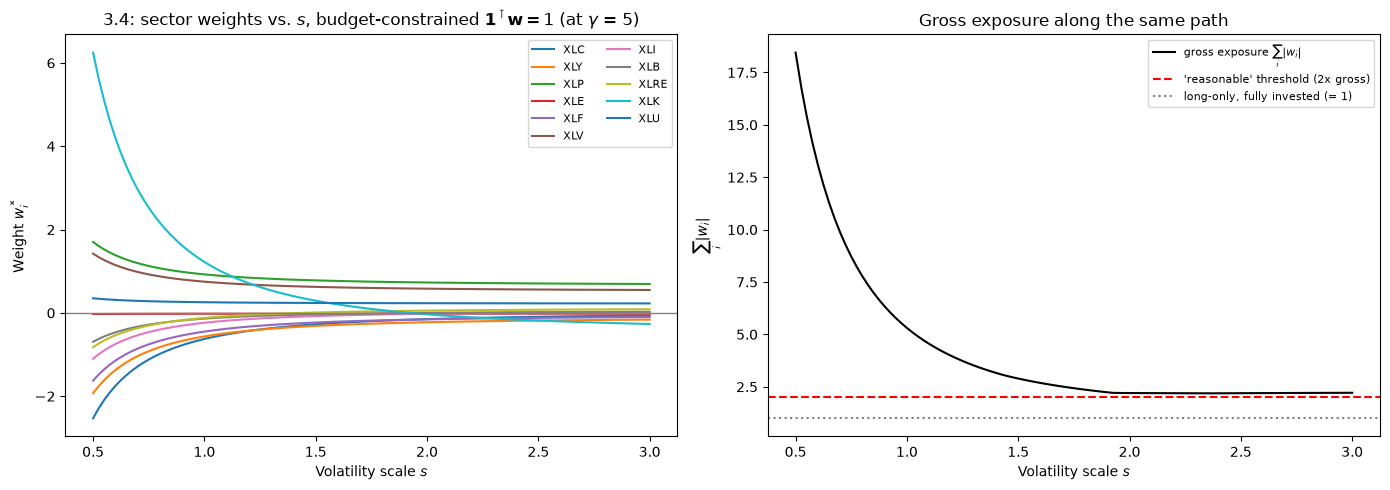

Sigma(s) = s^2 * Sigma_base at s=2: True
Correlations unchanged at s=2: True
Unconstrained w*(s) is exactly w*(1)/s^2 at every s: True
Budget-constrained: scaling volatility by s == raising gamma to gamma*s^2 (checked at s=2): True
Two-fund form  w*(s) = w_minvar + z_tilt / (gamma s^2)  holds along the whole grid: True


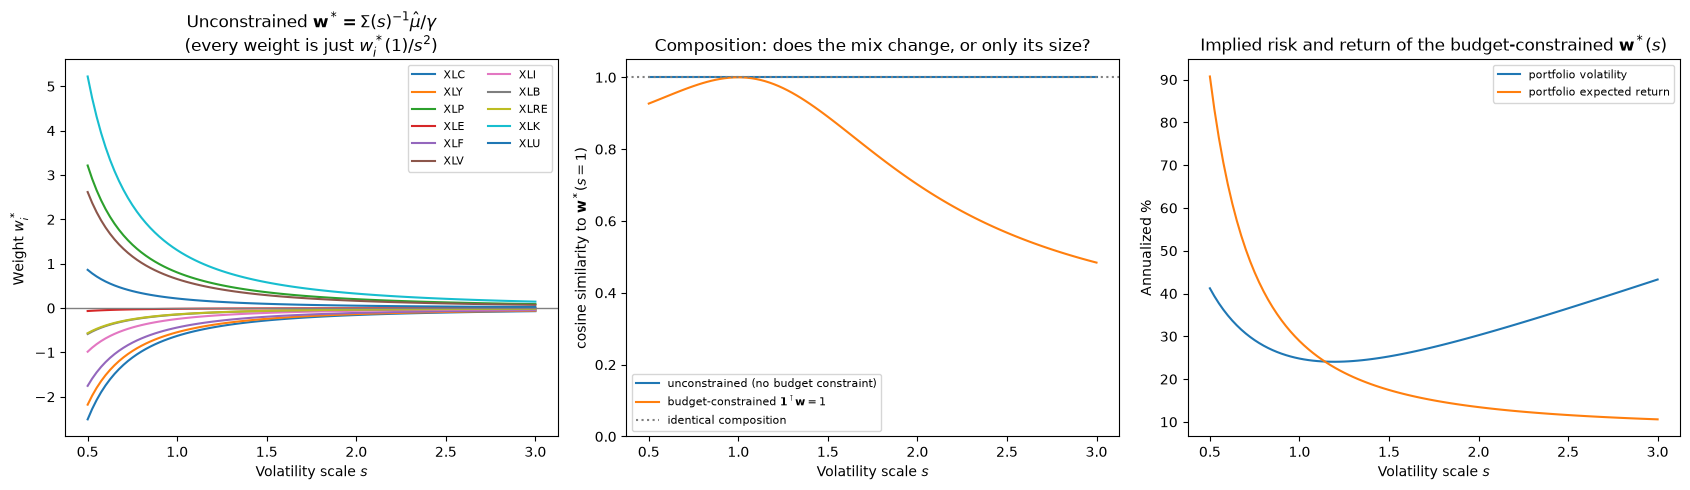


Budget-constrained weight vector at selected s:


,s=0.5,s=1,s=1.5,s=2,s=3
XLC,-2.528,-0.626,-0.274,-0.150,-0.062
XLY,-1.927,-0.565,-0.312,-0.224,-0.161
XLP,1.702,0.925,0.781,0.730,0.694
XLE,-0.027,-0.020,-0.018,-0.018,-0.018
XLF,-1.625,-0.449,-0.231,-0.155,-0.100
XLV,1.422,0.750,0.625,0.582,0.550
XLI,-1.100,-0.237,-0.077,-0.021,0.019
XLB,-0.693,-0.137,-0.035,0.001,0.027
XLRE,-0.823,-0.121,0.009,0.055,0.087
XLK,6.248,1.223,0.293,-0.033,-0.266


,gross_leverage,max_long,max_short,gross (unconstrained),portfolio vol (ann %)
0.5,18.45,6.25,-2.53,20.56,41.22
1.0,5.31,1.22,-0.63,5.14,24.80
1.5,2.89,0.78,-0.31,2.28,25.30
2.0,2.20,0.73,-0.22,1.28,30.25
3.0,2.21,0.69,-0.27,0.57,43.28


In [13]:
# --- 3.4: Sigma(s) = (sD) C (sD) -- scale every volatility by s, leave every correlation alone ---
def sigma_scaled(s):
    Ds = s * D_base
    return np.outer(Ds, Ds) * C_base


S_GRID = np.linspace(0.5, 3.0, 101)
W_s = weight_path(S_GRID, lambda s: mpt_weights(mu_base, sigma_scaled(s), GAMMA_BASE))
# The same sweep without the budget constraint: w*_unc = (1/gamma) Sigma(s)^-1 mu
W_s_unc = weight_path(S_GRID, lambda s: np.linalg.solve(sigma_scaled(s), mu_base) / GAMMA_BASE)

diag_s = plot_weight_path(
    W_s, r"Volatility scale $s$",
    rf"3.4: sector weights vs. $s$, budget-constrained $\mathbf{{1}}^\intercal \mathbf{{w}} = 1$ (at $\gamma$ = {GAMMA_BASE:g})",
)

# Structural checks: does the construction do what it claims, and how does w* respond?
print(f"Sigma(s) = s^2 * Sigma_base at s=2: {np.allclose(sigma_scaled(2.0), 4 * Sigma_base)}")
S2 = sigma_scaled(2.0)
print(f"Correlations unchanged at s=2: {np.allclose(S2 / np.outer(np.sqrt(np.diag(S2)), np.sqrt(np.diag(S2))), C_base)}")
w_unc_1 = np.linalg.solve(Sigma_base, mu_base) / GAMMA_BASE      # the s = 1 unconstrained solution
print(f"Unconstrained w*(s) is exactly w*(1)/s^2 at every s: "
      f"{np.allclose(W_s_unc.values, np.outer(1 / S_GRID**2, w_unc_1))}")
print(f"Budget-constrained: scaling volatility by s == raising gamma to gamma*s^2 (checked at s=2): "
      f"{np.allclose(mpt_weights(mu_base, sigma_scaled(2.0), GAMMA_BASE), mpt_weights(mu_base, Sigma_base, GAMMA_BASE * 4))}")
print(f"Two-fund form  w*(s) = w_minvar + z_tilt / (gamma s^2)  holds along the whole grid: "
      f"{np.allclose(W_s.values, w_minvar + np.outer(1 / (GAMMA_BASE * S_GRID**2), z_tilt))}")

# Composition vs. scale: cosine similarity to the s = 1 portfolio isolates direction from size.
w_s1 = mpt_weights(mu_base, Sigma_base, GAMMA_BASE)
w_s1_unc = w_unc_1
cos_con = W_s.values @ w_s1 / (np.linalg.norm(W_s.values, axis=1) * np.linalg.norm(w_s1))
cos_unc = W_s_unc.values @ w_s1_unc / (np.linalg.norm(W_s_unc.values, axis=1) * np.linalg.norm(w_s1_unc))
vol_ann = np.array([np.sqrt(W_s.iloc[i].values @ sigma_scaled(s) @ W_s.iloc[i].values * 252) * 100
                    for i, s in enumerate(S_GRID)])
ret_ann = W_s.values @ mu_base * 252 * 100

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for t in TICKERS:
    axes[0].plot(S_GRID, W_s_unc[t], label=t)
axes[0].axhline(0, color="gray", linewidth=1)
axes[0].set_xlabel("Volatility scale $s$")
axes[0].set_ylabel(r"Weight $w_i^*$")
axes[0].set_title(r"Unconstrained $\mathbf{w}^* = \Sigma(s)^{-1}\hat{\mu}/\gamma$" "\n" r"(every weight is just $w_i^*(1)/s^2$)")
axes[0].legend(ncol=2, fontsize=8)

axes[1].plot(S_GRID, cos_unc, label="unconstrained (no budget constraint)")
axes[1].plot(S_GRID, cos_con, label=r"budget-constrained $\mathbf{1}^\intercal\mathbf{w}=1$")
axes[1].axhline(1.0, color="gray", linestyle=":", label="identical composition")
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("Volatility scale $s$")
axes[1].set_ylabel(r"cosine similarity to $\mathbf{w}^*(s=1)$")
axes[1].set_title("Composition: does the mix change, or only its size?")
axes[1].legend(fontsize=8)

axes[2].plot(S_GRID, vol_ann, label="portfolio volatility")
axes[2].plot(S_GRID, ret_ann, label="portfolio expected return")
axes[2].set_xlabel("Volatility scale $s$")
axes[2].set_ylabel("Annualized %")
axes[2].set_title("Implied risk and return of the budget-constrained $\\mathbf{w}^*(s)$")
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

S_SHOW = [0.5, 1.0, 1.5, 2.0, 3.0]
s_table = weight_path(S_SHOW, lambda s: mpt_weights(mu_base, sigma_scaled(s), GAMMA_BASE)).T
s_table.columns = [f"s={s:g}" for s in S_SHOW]
print("\nBudget-constrained weight vector at selected s:")
display(s_table.round(3))
s_summary = path_diagnostics(weight_path(S_SHOW, lambda s: mpt_weights(mu_base, sigma_scaled(s), GAMMA_BASE)))
s_summary["gross (unconstrained)"] = [np.abs(np.linalg.solve(sigma_scaled(s), mu_base) / GAMMA_BASE).sum() for s in S_SHOW]
s_summary["portfolio vol (ann %)"] = [np.sqrt(mpt_weights(mu_base, sigma_scaled(s), GAMMA_BASE) @ sigma_scaled(s)
                                              @ mpt_weights(mu_base, sigma_scaled(s), GAMMA_BASE) * 252) * 100 for s in S_SHOW]
display(s_summary.round(2))

**Taking $\mathbf{w}^*$ literally: composition is exactly invariant.** For the pure solution $\mathbf{w}^* = \boldsymbol\Sigma^{-1}\boldsymbol\mu/\gamma$ with no budget constraint, $\boldsymbol\Sigma(s) = s^2\boldsymbol\Sigma$ gives $\mathbf{w}^*(s) = \mathbf{w}^*(1)/s^2$ -- every weight divided by the same number, verified at every point on the grid. Cosine similarity to the $s=1$ portfolio is 1.000000 throughout (left and middle panels). Doubling every volatility quarters the position and changes nothing about the mix. That is the clean answer to the question as asked: volatility scaling sets the *size* of the bet, not its composition.

**Under the fully-invested constraint, the mix slides along one line.** Requiring $\mathbf{1}^\intercal\mathbf{w} = 1$ forbids that uniform rescale -- something has to absorb what deleveraging would have moved to cash. The exact result is the two-fund form $\mathbf{w}^*(s) = \mathbf{w}_{\text{minvar}} + \mathbf{z}/(\gamma s^2)$, checked numerically above: the min-variance anchor is fixed and only the tilt shrinks, by $1/s^2$. Gross exposure falls 18.45, 5.31, 2.20 at $s = 0.5, 1, 2$, and cosine similarity to $\mathbf{w}^*(1)$ drops to 0.48 by $s = 3$. So the composition does move, but along a single line toward minimum variance -- it never rotates into a different set of bets.

**Volatility scaling is the third face of the same dial.** Scaling all volatilities by $s$ is exactly equivalent to raising $\gamma$ to $\gamma s^2$, verified at $s = 2$. Together with 3.2's $\alpha \equiv \gamma/(1-\alpha)$, all three of 3.1, 3.2 and 3.4 move the portfolio along the same segment between $\mathbf{w}_{\text{minvar}}$ and the tilt direction. Only 3.3 changes the direction $\mathbf{z}$ itself, which is why it is the sub-part where the answer can genuinely surprise you.

**Implied risk does not simply rise with $s$.** Portfolio volatility is U-shaped: 41.2% annualized at $s = 0.5$, a minimum of 24.1% near $s = 1.2$, then 43.3% at $s = 3$. Below $s \approx 1.2$ the deleveraging from the shrinking tilt outruns the volatility being scaled up. Expected return falls monotonically, 90.7% to 10.6%. Worth flagging because "I scaled my covariance estimate up, so the portfolio must be more conservative" is wrong in both directions here.

### Section 3.5 - A Dose of Realism: Constrained Weights

SLSQP with budget constraint only reproduces the closed-form w*: max abs deviation = 7.19e-07
Long-only solver converged: True   gross-cap solver converged: True
Gross cap is binding: sum|w| = 2.000 (cap = 2);  auxiliary u equals |w| at the optimum: True

Constrained vs. unconstrained (all evaluated at the same mu_base, Sigma_base, gamma):


,expected return (ann %),volatility (ann %),"Sharpe (ann, rf = 0)",gross exposure,largest long,largest short,# short positions,utility U (annualized),utility given up,% of unconstrained U
unconstrained (3.1-3.4),28.9103,24.8025,1.1656,5.3081,1.2231,-0.6258,7,0.1353,0.0000,0.0000
long-only,13.6850,17.7765,0.7698,1.0000,0.5536,0.0000,0,0.0578,0.0775,57.2481
gross <= 2,17.5856,18.2786,0.9621,2.0000,0.6363,-0.2330,3,0.0923,0.0430,31.7658



Weight vectors side by side:


,unconstrained (3.1-3.4),long-only,gross <= 2
XLC,-0.626,0.000,-0.233
XLY,-0.565,0.000,-0.099
XLP,0.925,0.554,0.636
XLE,-0.020,0.000,-0.000
XLF,-0.449,0.000,-0.168
XLV,0.750,0.182,0.312
XLI,-0.237,0.000,0.000
XLB,-0.137,0.000,0.000
XLRE,-0.121,0.000,0.000
XLK,1.223,0.177,0.427


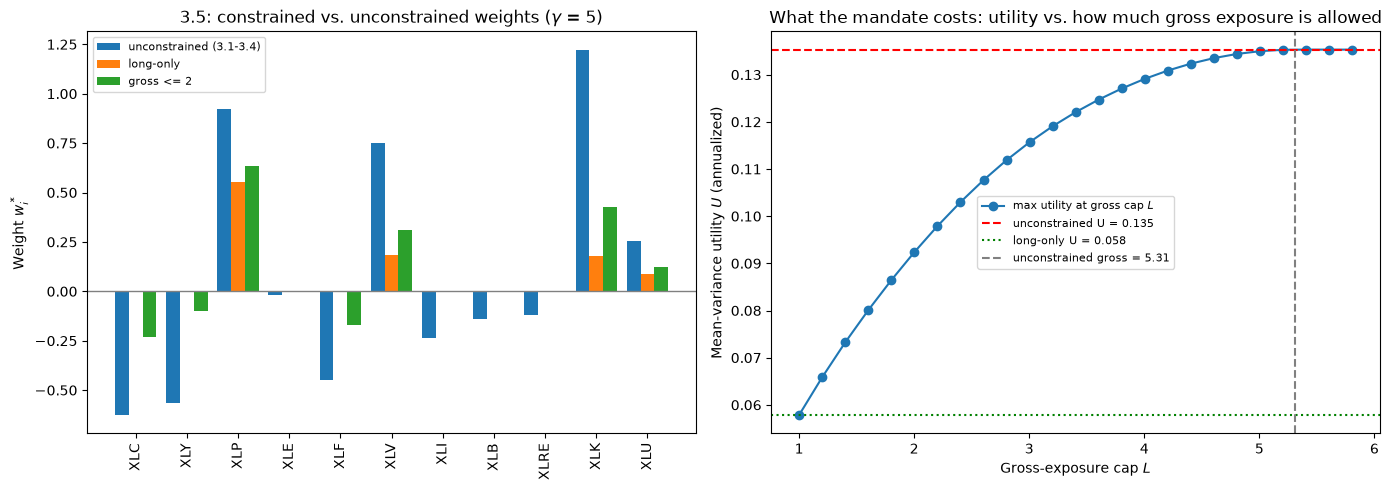

In [14]:
# --- 3.5: re-solve for w* under two mandate constraints, using the same mu_base / Sigma_base ---
LEV_CAP = 2.0   # gross-exposure cap: sum_i |w_i| <= 2, i.e. 2-to-1 gross


def mv_utility(w, mu=mu_base, Sigma=Sigma_base, gamma=GAMMA_BASE):
    """Mean-variance objective U(w) = w'mu - (gamma/2) w'Sigma w, annualized so the solver
    works on numbers of order 0.1 rather than 1e-4 (the argmax is unchanged by the x252)."""
    return 252.0 * (w @ mu - 0.5 * gamma * w @ Sigma @ w)


def solve_weights(bounds, extra_constraints=(), n_var=None):
    """Maximize mv_utility(w) subject to 1'w = 1 plus whatever else is passed in, via SLSQP.
    Variables past the first k are auxiliary (used by the leverage reformulation below)."""
    n_var = n_var or len(TICKERS)
    constraints = [{"type": "eq", "fun": lambda v: v[:len(TICKERS)].sum() - 1.0}] + list(extra_constraints)
    x0 = np.full(n_var, 1.0 / len(TICKERS))
    res = minimize(lambda v: -mv_utility(v[:len(TICKERS)]), x0, method="SLSQP",
                   bounds=bounds, constraints=constraints, options={"maxiter": 1000, "ftol": 1e-14})
    return res


# Sanity check: with only the budget constraint, SLSQP must land on the closed form from module 2.
res_check = solve_weights(bounds=[(-10.0, 10.0)] * K)
print(f"SLSQP with budget constraint only reproduces the closed-form w*: "
      f"max abs deviation = {np.abs(res_check.x - w_base).max():.2e}")

# Constraint 1 -- long-only: w_i >= 0 (with 1'w = 1 this also caps gross exposure at 1).
res_long = solve_weights(bounds=[(0.0, 1.0)] * K)
w_long = res_long.x

# Constraint 2 -- gross-exposure cap. sum|w_i| is not differentiable, so introduce u_i >= |w_i|
# (as u_i - w_i >= 0 and u_i + w_i >= 0) and cap sum(u_i). At the optimum u_i = |w_i|, so this
# is an exact smooth reformulation rather than a relaxation.
lev_constraints = [
    {"type": "ineq", "fun": lambda v: v[K:] - v[:K]},
    {"type": "ineq", "fun": lambda v: v[K:] + v[:K]},
    {"type": "ineq", "fun": lambda v: LEV_CAP - v[K:].sum()},
]
res_lev = solve_weights(bounds=[(-5.0, 5.0)] * K + [(0.0, 5.0)] * K,
                        extra_constraints=lev_constraints, n_var=2 * K)
w_lev = res_lev.x[:K]
print(f"Long-only solver converged: {res_long.success}   gross-cap solver converged: {res_lev.success}")
print(f"Gross cap is binding: sum|w| = {np.abs(w_lev).sum():.3f} (cap = {LEV_CAP:g});  "
      f"auxiliary u equals |w| at the optimum: {np.allclose(res_lev.x[K:], np.abs(w_lev), atol=1e-6)}")

# --- Compare the three portfolios ---
portfolios = {"unconstrained (3.1-3.4)": w_base, "long-only": w_long, f"gross <= {LEV_CAP:g}": w_lev}
U_unc = mv_utility(w_base)

compare = pd.DataFrame({
    "expected return (ann %)": [w @ mu_base * 252 * 100 for w in portfolios.values()],
    "volatility (ann %)": [np.sqrt(w @ Sigma_base @ w * 252) * 100 for w in portfolios.values()],
    "Sharpe (ann, rf = 0)": [(w @ mu_base * 252) / np.sqrt(w @ Sigma_base @ w * 252) for w in portfolios.values()],
    "gross exposure": [np.abs(w).sum() for w in portfolios.values()],
    "largest long": [w.max() for w in portfolios.values()],
    "largest short": [w.min() for w in portfolios.values()],
    "# short positions": [int((w < -1e-6).sum()) for w in portfolios.values()],
    "utility U (annualized)": [mv_utility(w) for w in portfolios.values()],
}, index=list(portfolios))
compare["utility given up"] = U_unc - compare["utility U (annualized)"]
compare["% of unconstrained U"] = compare["utility given up"] / abs(U_unc) * 100
print("\nConstrained vs. unconstrained (all evaluated at the same mu_base, Sigma_base, gamma):")
display(compare.round(4))

weights_compare = pd.DataFrame(portfolios, index=TICKERS)
print("\nWeight vectors side by side:")
display(weights_compare.round(3))

# --- How much does the cap cost as it is loosened? Sweep L from long-only to unconstrained. ---
LEV_GRID = np.linspace(1.0, np.abs(w_base).sum() + 0.5, 25)
lev_utils, lev_gross = [], []
for L in LEV_GRID:
    cons_L = [{"type": "ineq", "fun": lambda v: v[K:] - v[:K]},
              {"type": "ineq", "fun": lambda v: v[K:] + v[:K]},
              {"type": "ineq", "fun": (lambda L_: (lambda v: L_ - v[K:].sum()))(L)}]
    r = solve_weights(bounds=[(-6.0, 6.0)] * K + [(0.0, 6.0)] * K, extra_constraints=cons_L, n_var=2 * K)
    lev_utils.append(mv_utility(r.x[:K]))
    lev_gross.append(np.abs(r.x[:K]).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(portfolios))
width = 0.27
for j, (name, w) in enumerate(portfolios.items()):
    axes[0].bar(np.arange(K) + (j - 1) * width, w, width, label=name)
axes[0].axhline(0, color="gray", linewidth=1)
axes[0].set_xticks(np.arange(K)); axes[0].set_xticklabels(TICKERS, rotation=90)
axes[0].set_ylabel(r"Weight $w_i^*$")
axes[0].set_title(rf"3.5: constrained vs. unconstrained weights ($\gamma$ = {GAMMA_BASE:g})")
axes[0].legend(fontsize=8)

axes[1].plot(LEV_GRID, lev_utils, marker="o", label="max utility at gross cap $L$")
axes[1].axhline(U_unc, color="red", linestyle="--", label=f"unconstrained U = {U_unc:.3f}")
axes[1].axhline(mv_utility(w_long), color="green", linestyle=":", label=f"long-only U = {mv_utility(w_long):.3f}")
axes[1].axvline(np.abs(w_base).sum(), color="gray", linestyle="--",
                label=f"unconstrained gross = {np.abs(w_base).sum():.2f}")
axes[1].set_xlabel("Gross-exposure cap $L$")
axes[1].set_ylabel("Mean-variance utility $U$ (annualized)")
axes[1].set_title("What the mandate costs: utility vs. how much gross exposure is allowed")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

**Constraints chosen.** Long-only ($w_i \ge 0$), the typical retail or institutional mandate, and a gross-exposure cap $\sum_i|w_i| \le 2$, the way a long/short fund usually bounds risk. Both keep the budget constraint, so all three portfolios are fully invested and the utilities are directly comparable. As written, the gross cap is not differentiable, so it is reformulated with auxiliary variables $u_i \ge |w_i|$ (as $u_i - w_i \ge 0$ and $u_i + w_i \ge 0$) and a cap on $\sum_i u_i$. At the optimum $u_i = |w_i|$ exactly, confirmed in the output, so this is an exact reformulation and not a relaxation. Before trusting SLSQP on the constrained problems, I ran it with only the budget constraint: it reproduces module 2's closed form to $7\times10^{-7}$.

**What changed.**

| | unconstrained | long-only | gross $\le 2$ |
|---|---|---|---|
| Gross exposure | 5.31 | 1.00 | 2.00 |
| Short positions | 7 | 0 | 3 |
| Largest position | $+1.22$ (XLK) | $+0.55$ (XLP) | $+0.64$ (XLP) |
| Expected return (ann.) | 28.9% | 13.7% | 17.6% |
| Volatility (ann.) | 24.8% | 17.8% | 18.3% |
| Sharpe (ann., $r_f = 0$) | 1.17 | 0.77 | 0.96 |
| Utility $U$ (ann.) | 0.135 | 0.058 | 0.092 |
| **Utility given up** | -- | **0.078 (57.2%)** | **0.043 (31.8%)** |

Long-only gives up 57.2% of the mean-variance objective and collapses to four positions, all defensive or low-beta: XLP 55%, XLV 18%, XLK 18%, XLU 9%. The gross cap gives up only 31.8% while retaining small shorts in exactly the three sectors the unconstrained solution shorted hardest (XLC, XLF, XLY), and it does so at a fifth of the concentration. Per unit of utility surrendered, the leverage cap is much the better mandate here.

**The cost curve.** The right panel sweeps the cap $L$ from 1 to past the unconstrained gross of 5.31. Utility is concave in $L$, steep from $L=1$ to $L=3$ and flat once $L$ exceeds 5.31, where the constraint stops binding and the closed-form solution is recovered. Note that $L = 1$ combined with full investment *is* long-only, which is why both report $U = 0.058$.

**Read the 57% with suspicion.** All three utilities are computed ex ante with the same $\hat{\boldsymbol\mu}$ that produced the unconstrained portfolio, so the unconstrained portfolio wins by construction -- it is being graded on the exam it wrote. Section 2 is the reason to discount it: 2.3's bootstrap put 8 of 11 sector means' 95% intervals across zero, and 2.1 found $\hat{\boldsymbol\mu}$'s relative error above 1 until roughly $n = 1{,}000$. Most of the utility a constraint "gives up" is the value of bets we have little evidence are real. The out-of-sample results in Sections 4 and 5 are the test that actually settles it.

## Section 4 - The Effect of Rebalancing and Trading Costs

### Section 4.1 - Frictionless Rebalancing

In [ ]:
from IPython.display import Markdown

# Use one chronological split for all of Section 4.  Nothing from the test set enters the estimates.
split_4 = int(0.60 * len(returns))
train_4 = returns.iloc[:split_4].copy()
test_4 = returns.iloc[split_4:].copy()

# Re-estimate both models from Section 2 on training data only.
mu_sample_4 = train_4[TICKERS].mean().to_numpy()
Sigma_sample_4 = train_4[TICKERS].cov().to_numpy()

X_4 = np.column_stack([np.ones(len(train_4)), train_4[MARKET].to_numpy()])
Y_4 = train_4[TICKERS].to_numpy()
B_4 = np.linalg.lstsq(X_4, Y_4, rcond=None)[0]
resids_4 = Y_4 - X_4 @ B_4
mu_capm_4 = B_4[0] + B_4[1] * train_4[MARKET].mean()
Sigma_capm_4 = (np.outer(B_4[1], B_4[1]) * train_4[MARKET].var(ddof=1)
                + np.diag(resids_4.var(axis=0, ddof=1)))

GAMMA_4 = 5.0
w_sample_4 = np.linalg.solve(Sigma_sample_4, mu_sample_4) / GAMMA_4
w_capm_4 = np.linalg.solve(Sigma_capm_4, mu_capm_4) / GAMMA_4
w_ew_4 = np.repeat(1 / len(TICKERS), len(TICKERS))

# Daily rebalancing holds each target weight constant.  The unconstrained MPT portfolios
# may leave an implicit cash position, whose return is zero (our stated risk-free rate).
frictionless_returns_4 = pd.DataFrame({
    "Sample MPT": test_4[TICKERS].to_numpy() @ w_sample_4,
    "CAPM MPT": test_4[TICKERS].to_numpy() @ w_capm_4,
    "Equal weight": test_4[TICKERS].to_numpy() @ w_ew_4,
    "SPY": test_4[MARKET].to_numpy(),
}, index=test_4.index)

def performance_metrics_4(return_df):
    wealth = (1 + return_df).cumprod()
    drawdown = wealth.div(wealth.cummax()).sub(1)
    return pd.DataFrame({
        "Cumulative return": wealth.iloc[-1] - 1,
        "Annualized Sharpe (rf=0)": np.sqrt(252) * return_df.mean() / return_df.std(ddof=1),
        "Maximum drawdown": drawdown.min(),
        "Annualized volatility": return_df.std(ddof=1) * np.sqrt(252),
    })

frictionless_metrics_4 = performance_metrics_4(frictionless_returns_4)
print(f"Train: {train_4.index[0].date()} to {train_4.index[-1].date()} ({len(train_4)} days)")
print(f"Test:  {test_4.index[0].date()} to {test_4.index[-1].date()} ({len(test_4)} days)")
print(f"Risk aversion gamma = {GAMMA_4:g}; risk-free rate = 0")
display(frictionless_metrics_4.style.format({
    "Cumulative return": "{:.2%}",
    "Annualized Sharpe (rf=0)": "{:.3f}",
    "Maximum drawdown": "{:.2%}",
    "Annualized volatility": "{:.2%}",
}))

frictionless_wealth_4 = (1 + frictionless_returns_4).cumprod()
ax = frictionless_wealth_4.plot(figsize=(12, 5), linewidth=1.5)
ax.set_title("Section 4.1: frictionless out-of-sample cumulative wealth")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.axhline(1, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

best_sharpe_4 = frictionless_metrics_4["Annualized Sharpe (rf=0)"].idxmax()
best_return_4 = frictionless_metrics_4["Cumulative return"].idxmax()
sample_stats_4 = frictionless_metrics_4.loc["Sample MPT"]
capm_stats_4 = frictionless_metrics_4.loc["CAPM MPT"]
ew_stats_4 = frictionless_metrics_4.loc["Equal weight"]
spy_stats_4 = frictionless_metrics_4.loc["SPY"]
display(Markdown(
    f"**Frictionless comparison.** {best_sharpe_4} has the highest Sharpe "
    f"({frictionless_metrics_4.loc[best_sharpe_4, 'Annualized Sharpe (rf=0)']:.3f}) and "
    f"{best_return_4} has the highest cumulative return "
    f"({frictionless_metrics_4.loc[best_return_4, 'Cumulative return']:.1%}). "
    f"Sample MPT returned {sample_stats_4['Cumulative return']:.1%} with Sharpe "
    f"{sample_stats_4['Annualized Sharpe (rf=0)']:.3f}, versus {ew_stats_4['Cumulative return']:.1%} "
    f"and {ew_stats_4['Annualized Sharpe (rf=0)']:.3f} for equal weight and "
    f"{spy_stats_4['Cumulative return']:.1%} and {spy_stats_4['Annualized Sharpe (rf=0)']:.3f} for SPY. "
    f"CAPM MPT returned {capm_stats_4['Cumulative return']:.1%} with Sharpe "
    f"{capm_stats_4['Annualized Sharpe (rf=0)']:.3f}. Its volatility/drawdown were "
    f"{capm_stats_4['Annualized volatility']:.1%}/{capm_stats_4['Maximum drawdown']:.1%}, compared with "
    f"{spy_stats_4['Annualized volatility']:.1%}/{spy_stats_4['Maximum drawdown']:.1%} for SPY."
))

### Section 4.2 - Introducing Transaction Costs

In [ ]:
# Put every strategy in the same 12-column universe; unused assets receive zero weight.
assets_4 = TICKERS + [MARKET]
test_asset_returns_4 = test_4[assets_4]
targets_4 = {
    "Sample MPT": np.r_[w_sample_4, 0.0],
    "CAPM MPT": np.r_[w_capm_4, 0.0],
    "Equal weight": np.r_[w_ew_4, 0.0],
    "SPY": np.r_[np.zeros(len(TICKERS)), 1.0],
}

def rebalance_days_4(index, frequency):
    if frequency == "Daily":
        return np.ones(len(index), dtype=bool)
    period_code = {"Weekly": "W-FRI", "Monthly": "M", "Quarterly": "Q"}[frequency]
    periods = index.to_period(period_code)
    flags = np.r_[True, periods[1:] != periods[:-1]]
    return flags

def simulate_costs_4(asset_returns, target, frequency, cost_bps, fee_bps_year=50):
    """Fixed-target backtest with drift, pre-return trading costs, and a daily fee."""
    rebalance = rebalance_days_4(asset_returns.index, frequency)
    drifted = np.zeros(len(target))  # all cash immediately before the initial investment
    daily_fee = fee_bps_year * 1e-4 / 252
    net_returns, turnovers = [], []

    for i, row in enumerate(asset_returns.to_numpy()):
        turnover = np.abs(target - drifted).sum() if rebalance[i] else 0.0
        if rebalance[i]:
            drifted = target.copy()

        cost_rate = turnover * cost_bps * 1e-4
        gross_portfolio_return = drifted @ row
        # Trading cost is deducted before the day's return; the annual fee is an additive daily haircut.
        net_return = (1 - cost_rate) * (1 + gross_portfolio_return - daily_fee) - 1
        net_returns.append(net_return)
        turnovers.append(turnover)

        growth_before_fee = 1 + gross_portfolio_return
        if growth_before_fee <= 0:
            raise ValueError("Portfolio value became non-positive; choose a larger gamma.")
        drifted = drifted * (1 + row) / growth_before_fee

    return (pd.Series(net_returns, index=asset_returns.index),
            pd.Series(turnovers, index=asset_returns.index))

FREQUENCIES_4 = ["Daily", "Weekly", "Monthly", "Quarterly"]
COST_LEVELS_4 = [1, 5, 10, 20]
MANAGEMENT_FEE_BPS_4 = 50
records_4 = []
net_returns_4 = {}

for strategy, target in targets_4.items():
    for frequency in FREQUENCIES_4:
        for cost_bps in COST_LEVELS_4:
            net, turnover = simulate_costs_4(
                test_asset_returns_4, target, frequency, cost_bps, MANAGEMENT_FEE_BPS_4
            )
            key = (strategy, frequency, cost_bps)
            net_returns_4[key] = net
            records_4.append({
                "Strategy": strategy,
                "Frequency": frequency,
                "Cost (bps)": cost_bps,
                "Net Sharpe": np.sqrt(252) * net.mean() / net.std(ddof=1),
                "Net cumulative return": (1 + net).prod() - 1,
                "Annualized volatility": net.std(ddof=1) * np.sqrt(252),
                "Total turnover": turnover.sum(),
                "Total trading cost": (turnover * cost_bps * 1e-4).sum(),
            })

cost_results_4 = pd.DataFrame(records_4)
sharpe_table_4 = cost_results_4.pivot_table(
    index=["Strategy", "Frequency"], columns="Cost (bps)", values="Net Sharpe"
).reindex(pd.MultiIndex.from_product([targets_4, FREQUENCIES_4], names=["Strategy", "Frequency"]))
print(f"Net results include a {MANAGEMENT_FEE_BPS_4} bps/year management fee.")
display(sharpe_table_4.style.format("{:.3f}"))

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
for ax, strategy in zip(axes.flat, targets_4):
    subset = cost_results_4[cost_results_4["Strategy"] == strategy]
    for cost_bps in COST_LEVELS_4:
        line = subset[subset["Cost (bps)"] == cost_bps].set_index("Frequency").loc[FREQUENCIES_4]
        ax.plot(FREQUENCIES_4, line["Net Sharpe"], marker="o", label=f"{cost_bps} bps")
    ax.set_title(strategy)
    ax.set_ylabel("Net annualized Sharpe")
    ax.grid(alpha=0.25)
    ax.legend(title="Cost/traded $")
fig.suptitle("Section 4.2: rebalancing frequency and transaction-cost sensitivity", y=1.01)
plt.tight_layout()
plt.show()

optimal_frequency_4 = (cost_results_4.loc[
    cost_results_4.groupby(["Strategy", "Cost (bps)"])["Net Sharpe"].idxmax(),
    ["Strategy", "Cost (bps)", "Frequency", "Net Sharpe"]
].sort_values(["Strategy", "Cost (bps)"]).reset_index(drop=True))
print("Approximately optimal frequency at each cost level (chosen by net Sharpe):")
display(optimal_frequency_4.style.format({"Net Sharpe": "{:.3f}"}))

optimal_sentences_4 = []
for strategy in targets_4:
    rows = optimal_frequency_4[optimal_frequency_4["Strategy"] == strategy]
    choices = ", ".join(
        f"{int(row['Cost (bps)'])} bps: {row['Frequency']} (Sharpe {row['Net Sharpe']:.3f})"
        for _, row in rows.iterrows()
    )
    optimal_sentences_4.append(f"**{strategy}:** {choices}.")
frequency_changes_4 = optimal_frequency_4.groupby("Strategy")["Frequency"].nunique()
dependent_4 = frequency_changes_4[frequency_changes_4 > 1].index.tolist()
dependence_text_4 = (
    "The approximately optimal frequency therefore depends on transaction cost for "
    + ", ".join(dependent_4) + ". "
    if dependent_4 else
    "The approximately optimal frequency does not change over the tested cost grid for any strategy. "
)
display(Markdown(
    "**Trading-cost interpretation.** The Sharpe-maximizing choices are:\n\n"
    + "\n\n".join(optimal_sentences_4)
    + "\n\n" + dependence_text_4
    + "Higher transaction costs penalize frequent rebalancing because it repeatedly pays on turnover; "
      "the lower-frequency schedules allow weights to drift and trade less often. All results above are "
      f"net of both trading costs and the {MANAGEMENT_FEE_BPS_4} bps annual management fee."
))

## Section 5 - Full Backtester

### Section 5.1 - The Loop

**What the loop does.** For each day $t$ from the end of the burn-in ($T_0 = 252$, one year) to the second-to-last day of the sample, the loop (1) re-estimates $\hat{\boldsymbol\mu}_t$ and $\hat{\boldsymbol\Sigma}_t$ from returns **through day $t$ only**, (2) computes $\mathbf{w}^*_t$ from module 2's closed form, (3) if $t$ is the first trading day of a month, trades from the current *drifted* weights to $\mathbf{w}^*_t$ and pays transaction costs, and (4) applies day $t+1$'s returns. The net return that gets recorded is dated $t+1$.

**Timing, and why there is no lookahead.** The estimate at step 1 uses `returns.iloc[:t+1]`, which is days $1$ through $t$ inclusive. The trade at step 3 is executed at day $t$'s close, using only information available at that close. The return earned at step 4 is day $t+1$'s, which nothing in steps 1-3 has seen. This is deliberately the opposite of the prompt's warned-about off-by-one: estimating through day $t$ and then booking day $t$'s return would credit the strategy with a day it could not have traded on.

**Window choice: expanding.** Two findings from Section 2 point in opposite directions here. 2.1 says more data is unambiguously better — $\hat{\boldsymbol\mu}$'s relative error stays above 1 until roughly $n = 1{,}000$ — which argues for the longest window available. 2.3 says the estimates are regime-dependent, with $\hat{\boldsymbol\mu}$ flipping sign repeatedly, which argues for a short window that forgets old regimes. I use the **expanding** window, because at $k = 11$ assets the binding constraint is estimation noise rather than staleness: a 252-day rolling window re-estimates $\hat{\boldsymbol\mu}$ from exactly the sample size 2.1 showed to be worst-case unreliable, and it does so afresh every month, so the weights chase noise. The comparison below runs both and reports the cost of that choice, rather than asserting it.

**Which $\mathbf{w}^*$.** `mpt_weights` — module 2's closed form, maximizing $\mathbf{w}^\intercal\boldsymbol\mu - \tfrac{\gamma}{2}\mathbf{w}^\intercal\boldsymbol\Sigma\mathbf{w}$ subject to $\mathbf{1}^\intercal\mathbf{w} = 1$ — the same function and the same $\gamma = 5$ used throughout Section 3. Because the weights sum to one exactly, the book is always fully invested and there is no implicit cash position to account for.

**Cost model.** Identical to 4.2: turnover is measured against the drifted weights *after* price moves, and the cost $c \cdot \text{turnover}$ is charged to portfolio value *before* day $t+1$'s return is applied. I use $c = 10$ bps (the middle of the prompt's 1-20 bps range) and a management fee of $f = 50$ bps per year as a daily haircut. The fee is charged to the three active strategies only — a passive benchmark does not pay an active manager — while trading costs are charged to everyone, including the initial purchase.

**Rebalancing frequency: monthly**, the prompt's own example. 4.2 found quarterly marginally better than monthly on net Sharpe for a *fixed* target, but in a walk-forward setting rebalancing is also what refreshes the estimate, so monthly is the more natural default; the cost of that choice is small and quantified in the tearsheet's turnover line.

**What gets run.** The required unconstrained walk-forward, plus two variants that earn their place: the same strategy on a rolling 252-day window (to justify the window choice with evidence), and the same strategy with 3.5's gross-exposure cap $\sum_i|w_i| \le 2$ (which is what 5.3's "what would you change" question turns out to hinge on). Both passive benchmarks — equal weight, rebalanced monthly, and SPY — run through the identical simulator, so every number below is comparable line for line.


In [ ]:
# ============================ Section 5.1: the loop ============================
# Timing convention -- the single most important detail in this section:
#   estimate on returns.iloc[:t+1]   -> data THROUGH day t, nothing later
#   trade at day t's close           -> w_post
#   earn returns.iloc[t+1]           -> recorded as the net return dated t+1
from IPython.display import Markdown

T0_5 = 252              # burn-in: one year of history before the first trade
W_ROLL_5 = 252          # rolling-window length, used only for the window comparison
GAMMA_5 = GAMMA_BASE    # 5.0, the same risk aversion as all of Section 3
C_BPS_5 = 10.0          # transaction cost per dollar traded, in bps (middle of 4.2's range)
FEE_BPS_5 = 50.0        # management fee, bps/year, active strategies only
LEV_CAP_5 = LEV_CAP     # 2.0, the gross-exposure cap from 3.5
REBAL_5 = "Monthly"


def rebalance_flags(index, frequency, first_day=0):
    """Boolean mask of rebalancing days. `first_day` is forced True so the book starts invested."""
    if frequency == "Daily":
        flags = np.ones(len(index), dtype=bool)
    else:
        code = {"Weekly": "W-FRI", "Monthly": "M", "Quarterly": "Q"}[frequency]
        periods = index.to_period(code)
        flags = np.r_[True, periods[1:] != periods[:-1]]
    flags[first_day] = True
    return flags


def gross_capped_weights(mu, Sigma, gamma, cap=LEV_CAP_5):
    """3.5's constrained solve: maximize U(w) s.t. 1'w = 1 and sum_i |w_i| <= cap.
    Same exact smooth reformulation as 3.5 -- auxiliary u_i >= |w_i|, then cap sum(u)."""
    cons = [{"type": "eq",   "fun": lambda v: v[:K].sum() - 1.0},
            {"type": "ineq", "fun": lambda v: v[K:] - v[:K]},
            {"type": "ineq", "fun": lambda v: v[K:] + v[:K]},
            {"type": "ineq", "fun": lambda v: cap - v[K:].sum()}]
    res = minimize(lambda v: -(v[:K] @ mu - 0.5 * gamma * v[:K] @ Sigma @ v[:K]),
                   np.r_[np.full(K, 1.0 / K), np.full(K, 1.0 / K)], method="SLSQP",
                   bounds=[(-5.0, 5.0)] * K + [(0.0, 5.0)] * K,
                   constraints=cons, options={"maxiter": 300, "ftol": 1e-12})
    return res.x[:K]


def simulate(target_fn, frequency=REBAL_5, c_bps=C_BPS_5, fee_bps=0.0, T0=T0_5, assets=None):
    """Walk-forward simulator. `target_fn(t)` must return the target weights using data
    through day t only; the simulator supplies day t+1's return and never shows it to
    target_fn. Costs follow 4.2 exactly: turnover measured against the drifted weights,
    charged to portfolio value BEFORE the next day's return is applied.

    Returns the recorded series required by step 5 of the prompt's loop: net return,
    w*_t (the weights actually held), turnover_t and costs_t.
    """
    cols = list(assets) if assets is not None else TICKERS
    R = returns[cols].to_numpy()
    T = len(returns)
    rebal = rebalance_flags(returns.index, frequency, first_day=T0)
    fee_daily = fee_bps * 1e-4 / 252

    V = 1.0                              # portfolio value, starting from $1
    w_drift = np.zeros(len(cols))        # all cash immediately before the first trade
    dates, nets, turns, costs, weights = [], [], [], [], []

    for t in range(T0, T - 1):
        # 1-2. Fit on data through day t, then optimize.
        w_target = target_fn(t)

        # 3. Trade (rebalancing days only), against the DRIFTED weights.
        if rebal[t]:
            turnover = np.abs(w_target - w_drift).sum()
            w_post = w_target.copy()
        else:
            turnover, w_post = 0.0, w_drift
        cost_rate = turnover * c_bps * 1e-4
        cost_paid = V * cost_rate
        V *= (1.0 - cost_rate)           # cost leaves the portfolio BEFORE the next return

        # 4. Evolve: apply day t+1's returns.
        r_next = R[t + 1]
        gross_return = w_post @ r_next
        if 1.0 + gross_return <= 0.0:
            raise ValueError(f"portfolio wiped out on {returns.index[t + 1].date()} "
                             f"(one-day return {gross_return:.1%}); raise gamma or cap leverage")
        net_return = (1.0 - cost_rate) * (1.0 + gross_return - fee_daily) - 1.0
        V *= (1.0 + gross_return - fee_daily)

        # 5. Record.
        dates.append(returns.index[t + 1])
        nets.append(net_return)
        turns.append(turnover)
        costs.append(cost_paid)
        weights.append(w_post.copy())

        # Drift the weights on day t+1's price moves, ready for the next iteration.
        w_drift = w_post * (1.0 + r_next) / (1.0 + gross_return)

    idx = pd.DatetimeIndex(dates, name="date")
    return {"net": pd.Series(nets, index=idx, name="net_return"),
            "turnover": pd.Series(turns, index=idx, name="turnover"),
            "cost": pd.Series(costs, index=idx, name="cost"),
            "weights": pd.DataFrame(weights, index=idx, columns=cols)}


# --- Target-weight rules. Each closure only ever reads returns through day t. ---
def capm_mpt_target(window):
    def target(t):
        hist = returns.iloc[:t + 1] if window == "expanding" else returns.iloc[t + 1 - W_ROLL_5:t + 1]
        mu_t, Sigma_t = fit_capm(hist)
        return mpt_weights(mu_t, Sigma_t, GAMMA_5)
    return target


def capm_capped_target(window, cap=LEV_CAP_5):
    """Same estimate, but solved under the gross cap. SLSQP is ~1000x slower than the closed
    form, so the solve is memoized by calendar month; since the result is only ever *used* on
    the month's first trading day, the cached value is the one computed on that day."""
    cache = {}
    def target(t):
        key = returns.index[t].to_period("M")
        if key not in cache:
            hist = returns.iloc[:t + 1] if window == "expanding" else returns.iloc[t + 1 - W_ROLL_5:t + 1]
            mu_t, Sigma_t = fit_capm(hist)
            cache[key] = gross_capped_weights(mu_t, Sigma_t, GAMMA_5, cap)
        return cache[key]
    return target


w_ew_5 = np.full(K, 1.0 / K)
PRIMARY_5 = "MPT walk-forward (expanding)"
strategies_5 = {
    PRIMARY_5:                          dict(target_fn=capm_mpt_target("expanding"), fee_bps=FEE_BPS_5),
    "MPT walk-forward (rolling 252)":   dict(target_fn=capm_mpt_target("rolling"),   fee_bps=FEE_BPS_5),
    f"MPT + gross <= {LEV_CAP_5:g}":    dict(target_fn=capm_capped_target("expanding"), fee_bps=FEE_BPS_5),
    "Equal weight (benchmark)":         dict(target_fn=lambda t: w_ew_5,             fee_bps=0.0),
    "SPY (benchmark)":                  dict(target_fn=lambda t: np.ones(1),         fee_bps=0.0,
                                             assets=[MARKET]),
}
bt_5 = {name: simulate(**kw) for name, kw in strategies_5.items()}

primary_5 = bt_5[PRIMARY_5]
oos_start, oos_end = primary_5["net"].index[0], primary_5["net"].index[-1]
n_rebal_5 = int((primary_5["turnover"] > 0).sum())
print(f"Burn-in T0 = {T0_5} days; out-of-sample period {oos_start.date()} to {oos_end.date()} "
      f"({len(primary_5['net'])} days, {len(primary_5['net']) / 252:.1f} years)")
print(f"gamma = {GAMMA_5:g}, c = {C_BPS_5:g} bps, fee = {FEE_BPS_5:g} bps/yr (active only), "
      f"rebalanced {REBAL_5.lower()} -> {n_rebal_5} rebalances")

# Step 5 of the loop, as recorded (first and last few rebalancing days shown).
recorded_5 = pd.concat([primary_5["net"], primary_5["turnover"], primary_5["cost"],
                        primary_5["weights"].abs().sum(axis=1).rename("gross_exposure")], axis=1)
print("\nRecorded output on the first six rebalancing days:")
display(recorded_5[recorded_5["turnover"] > 0].head(6).round(4))

# --- Expanding vs. rolling: justify the window choice with numbers, not assertion ---
def _quick(res):
    r = res["net"]; wealth = (1 + r).cumprod()
    return (np.sqrt(252) * r.mean() / r.std(ddof=1),
            (wealth / wealth.cummax() - 1).min(),
            res["turnover"].sum() / (len(r) / 252),
            res["cost"].sum() * 100)
sh_e, dd_e, to_e, ct_e = _quick(bt_5[PRIMARY_5])
sh_r, dd_r, to_r, ct_r = _quick(bt_5["MPT walk-forward (rolling 252)"])
display(Markdown(
    f"**Window choice, settled empirically.** The expanding window turns over "
    f"{to_e:.1f}x of the book per year and pays {ct_e:.0f}% of initial capital in trading costs; "
    f"the 252-day rolling window turns over {to_r:.1f}x per year and pays {ct_r:.0f}%. "
    f"Rolling also runs a deeper drawdown ({dd_r:.0%} vs. {dd_e:.0%}) for a similar Sharpe "
    f"({sh_r:.2f} vs. {sh_e:.2f}). Re-estimating from only 252 days every month is exactly the "
    f"noise-chasing 2.1 predicts, and the turnover it generates is paid for in cash, so the "
    f"expanding window is used for everything that follows."
))

### Section 5.2 - Performance Report: The Tearsheet

In [ ]:
# ===================== Section 5.2: the tearsheet =====================
def tearsheet_metrics(res):
    """The six rows the prompt's tearsheet table asks for, plus final wealth for context."""
    r = res["net"]
    wealth = (1 + r).cumprod()
    years = len(r) / 252
    return pd.Series({
        "Annualized return": wealth.iloc[-1] ** (1 / years) - 1,
        "Annualized volatility": r.std(ddof=1) * np.sqrt(252),
        "Sharpe ratio": np.sqrt(252) * r.mean() / r.std(ddof=1),
        "Maximum drawdown": (wealth / wealth.cummax() - 1).min(),
        "Total turnover (annualized)": res["turnover"].sum() / years,
        "Total costs paid (% of initial capital)": res["cost"].sum() * 100,
        "Final wealth (per $1)": wealth.iloc[-1],
    })


tearsheet_5 = pd.DataFrame({name: tearsheet_metrics(res) for name, res in bt_5.items()})
# Each row carries its own units, so format row-wise into a display frame.
FMT_5 = {"Annualized return": "{:.2%}", "Annualized volatility": "{:.2%}",
         "Sharpe ratio": "{:.3f}", "Maximum drawdown": "{:.2%}",
         "Total turnover (annualized)": "{:.1f}x",
         "Total costs paid (% of initial capital)": "{:.1f}%",
         "Final wealth (per $1)": "${:.3f}"}
tearsheet_display_5 = pd.DataFrame(
    {name: [FMT_5[m].format(tearsheet_5.loc[m, name]) for m in tearsheet_5.index]
     for name in tearsheet_5.columns},
    index=tearsheet_5.index)
print(f"TEARSHEET -- out-of-sample, {oos_start.date()} to {oos_end.date()}, "
      f"net of {C_BPS_5:g} bps trading costs and a {FEE_BPS_5:g} bps/yr fee on active strategies. "
      f"Sharpe uses rf = 0.")
display(tearsheet_display_5)

wealth_5 = pd.DataFrame({name: (1 + res["net"]).cumprod() for name, res in bt_5.items()})

# --- Plot 1: cumulative wealth vs. both benchmarks ---
fig, ax = plt.subplots(figsize=(12, 5))
for name in wealth_5.columns:
    style = dict(linewidth=2.0) if name == PRIMARY_5 else dict(linewidth=1.2, alpha=0.85)
    ax.plot(wealth_5.index, wealth_5[name], label=name, **style)
ax.axhline(1.0, color="gray", linewidth=0.8)
ax.set_yscale("log")
ax.set_ylabel("Wealth per $1 invested (log scale)")
ax.set_title("5.2: out-of-sample cumulative wealth, net of costs and fees")
ax.legend(fontsize=8)
format_date_axis(ax)
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

# --- Plot 2: monthly turnover over time ---
turn_monthly_5 = primary_5["turnover"].groupby(primary_5["turnover"].index.to_period("M")).sum()
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.bar(turn_monthly_5.index.to_timestamp(), turn_monthly_5.values, width=20, color="tab:blue")
ax.axhline(turn_monthly_5.mean(), color="red", linestyle="--",
           label=f"mean {turn_monthly_5.mean():.2f}x per month")
ax.set_ylabel(r"Turnover $\sum_i |w^{target}_i - w^{drifted}_i|$")
ax.set_title(f"5.2: monthly turnover, {PRIMARY_5}")
ax.legend(fontsize=8)
format_date_axis(ax)
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

# --- Plot 3: portfolio weights over time (heatmap) + gross exposure ---
W5 = primary_5["weights"]
gross_5 = W5.abs().sum(axis=1)
clip = np.percentile(np.abs(W5.to_numpy()), 99)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[2.2, 1])
im = axes[0].imshow(W5.T, aspect="auto", cmap="coolwarm", vmin=-clip, vmax=clip,
                    extent=[mdates.date2num(W5.index[0]), mdates.date2num(W5.index[-1]), K, 0])
axes[0].set_yticks(np.arange(K) + 0.5)
axes[0].set_yticklabels(TICKERS)
axes[0].set_title(f"5.2: portfolio weights over time, {PRIMARY_5}\n"
                  f"(colour clipped at the 99th percentile, ±{clip:.2f}; blue = short, red = long)")
plt.colorbar(im, ax=axes[0], fraction=0.03, label=r"weight $w_{i,t}$")
axes[1].plot(gross_5.index, gross_5.values, color="black", linewidth=1)
axes[1].axhline(LEV_CAP_5, color="red", linestyle="--", label=f"3.5's gross cap ({LEV_CAP_5:g}x)")
axes[1].axhline(1.0, color="gray", linestyle=":", label="fully invested, long-only (= 1)")
axes[1].set_yscale("log")
axes[1].set_ylabel(r"gross exposure $\sum_i |w_i|$")
axes[1].set_title("Gross exposure of the same portfolio (log scale)")
axes[1].legend(fontsize=8)
for ax in axes:
    format_date_axis(ax)
    ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

# --- PM-facing recommendation ---
t5 = tearsheet_5
prim, capped = t5[PRIMARY_5], t5[f"MPT + gross <= {LEV_CAP_5:g}"]
ew, spy = t5["Equal weight (benchmark)"], t5["SPY (benchmark)"]
display(Markdown(
    f"**Recommendation to the PM.** I do not recommend allocating capital to this strategy as "
    f"specified. Over {len(primary_5['net']) / 252:.1f} years out of sample it returned "
    f"{prim['Annualized return']:.1%} annualized at {prim['Annualized volatility']:.0%} volatility "
    f"— a Sharpe of {prim['Sharpe ratio']:.2f} against {spy['Sharpe ratio']:.2f} for simply holding "
    f"SPY and {ew['Sharpe ratio']:.2f} for equal-weighting the same eleven sectors — and it did so "
    f"through a {prim['Maximum drawdown']:.0%} peak-to-trough drawdown, roughly "
    f"{prim['Maximum drawdown'] / spy['Maximum drawdown']:.1f}x the market's "
    f"{spy['Maximum drawdown']:.0%}. The mandate is also expensive to run: it turns over "
    f"{prim['Total turnover (annualized)']:.0f}x the book per year and pays "
    f"{prim['Total costs paid (% of initial capital)']:.0f}% of initial capital in trading costs, "
    f"which is the difference between ending at \\${prim['Final wealth (per $1)']:.2f} and "
    f"\\${spy['Final wealth (per $1)']:.2f} per dollar invested. The one version I would keep "
    f"on the shortlist "
    f"is the same signal under 3.5's gross-exposure cap, which lifts the drawdown to "
    f"{capped['Maximum drawdown']:.0%} and cuts costs to "
    f"{capped['Total costs paid (% of initial capital)']:.1f}% of capital while earning "
    f"{capped['Annualized return']:.1%} annualized; even that still trails both passive benchmarks, "
    f"so my condition for funding would be a demonstrated edge in \\(\\hat{{\\boldsymbol\\mu}}\\) that "
    f"Section 2 does not currently support, not a further tuning of the optimizer."
))

### Section 5.3 - Interpretation

In [ ]:
# ============ Section 5.3: supporting evidence for the interpretation ============
# (a) Costs, isolated: the identical strategy run with c = 0 and no fee, same period.
frictionless_5 = simulate(target_fn=capm_mpt_target("expanding"), c_bps=0.0, fee_bps=0.0)
cost_effect_5 = pd.DataFrame({
    "frictionless": tearsheet_metrics(frictionless_5),
    "net of costs and fee": tearsheet_metrics(primary_5),
})
cost_effect_5.loc["Cost drag (annualized return)"] = [
    np.nan, cost_effect_5.loc["Annualized return", "net of costs and fee"]
           - cost_effect_5.loc["Annualized return", "frictionless"]]
print("(a) Same strategy, same period, with and without frictions:")
display(cost_effect_5.round(4))

# (b) Common sub-period with Section 4.1, so the walk-forward and fixed-weight results are
#     measured over the identical window (4.1's test period starts at the 60% split).
sub_start_5 = returns.index[int(0.60 * len(returns))]
sub_rows_5 = {}
for name, res in bt_5.items():
    r = res["net"].loc[sub_start_5:]
    wealth = (1 + r).cumprod()
    sub_rows_5[name] = {
        "Annualized return": wealth.iloc[-1] ** (252 / len(r)) - 1,
        "Annualized volatility": r.std(ddof=1) * np.sqrt(252),
        "Sharpe ratio": np.sqrt(252) * r.mean() / r.std(ddof=1),
        "Maximum drawdown": (wealth / wealth.cummax() - 1).min(),
    }
sub_period_5 = pd.DataFrame(sub_rows_5).T
print(f"\n(b) Restricted to Section 4.1's test window ({sub_start_5.date()} onward):")
display(sub_period_5.round(4))

# (c) What the weights actually did: gross exposure by year, and concentration.
weights_year_5 = pd.DataFrame({
    "mean gross exposure": gross_5.groupby(gross_5.index.year).mean(),
    "max |single weight|": W5.abs().max(axis=1).groupby(W5.index.year).max(),
    "mean # short positions": (W5 < -1e-6).sum(axis=1).groupby(W5.index.year).mean(),
})
print("\n(c) Gross exposure and concentration, by calendar year:")
display(weights_year_5.round(2))
print("\nMean |weight| by sector over the whole out-of-sample period:")
display(W5.abs().mean().sort_values(ascending=False).to_frame("mean |w|").T.round(3))
print("\nCorrelation of daily net returns with SPY:")
display(pd.Series({name: res["net"].corr(bt_5["SPY (benchmark)"]["net"])
                   for name, res in bt_5.items() if name != "SPY (benchmark)"},
                  name="corr with SPY").to_frame().T.round(3))

In [ ]:
# ==================== Section 5.3: interpretation ====================
_p, _c = tearsheet_5[PRIMARY_5], tearsheet_5[f"MPT + gross <= {LEV_CAP_5:g}"]
_ew, _spy = tearsheet_5["Equal weight (benchmark)"], tearsheet_5["SPY (benchmark)"]
_fl = cost_effect_5["frictionless"]
_covid = {n: (1 + r["net"].loc["2020-02-20":"2020-04-30"]).prod() - 1 for n, r in bt_5.items()}
_sub = sub_period_5
_g19, _g25 = weights_year_5["mean gross exposure"].iloc[0], weights_year_5["mean gross exposure"].iloc[-2]
# Section 4.2's comparable figure: the same CAPM signal held at a FIXED training-period weight.
_s42 = cost_results_4.query("Strategy == 'CAPM MPT' and Frequency == 'Quarterly' and `Cost (bps)` == 10")["Net Sharpe"].iloc[0]
_rho = primary_5["net"].corr(bt_5["SPY (benchmark)"]["net"])

display(Markdown(f"""
**Does the walk-forward strategy beat the benchmarks, and where does the performance come from?**
No, and not narrowly. It earned {_p['Annualized return']:.1%} annualized against
{_spy['Annualized return']:.1%} for SPY and {_ew['Annualized return']:.1%} for equal weight, while
running {_p['Annualized volatility'] / _spy['Annualized volatility']:.1f}x the market's volatility
({_p['Annualized volatility']:.0%} vs. {_spy['Annualized volatility']:.0%}) — a Sharpe of
{_p['Sharpe ratio']:.2f} against {_spy['Sharpe ratio']:.2f} and {_ew['Sharpe ratio']:.2f}. The
underperformance is not a directional bet gone wrong: the strategy's daily returns are only
{_rho:.2f} correlated with SPY, so it is a levered long/short book rather than a sector tilt on the
market, and it actually *made* {_covid[PRIMARY_5]:+.0%} through the COVID crash while SPY lost
{abs(_covid['SPY (benchmark)']):.0%}. What it lacks is compensation for the risk it takes. The
gross exposure the optimizer demands — averaging {gross_5.mean():.1f}x, peaking near
{gross_5.max():.0f}x — multiplies estimation error in \\(\\hat{{\\boldsymbol\\mu}}\\) rather than any
real edge, which is exactly the mechanism Section 3.1 traced when it showed weights are hyperbolic
in \\(\\gamma\\) and Section 2.1 showed \\(\\hat{{\\boldsymbol\\mu}}\\)'s relative error exceeds 1 at
these sample sizes.

**How did transaction costs change the conclusion relative to the frictionless result?**
They made a bad result worse without changing the verdict. Run frictionless over the identical
period, the strategy returns {_fl['Annualized return']:.1%} annualized at Sharpe
{_fl['Sharpe ratio']:.2f}; net of {C_BPS_5:g} bps and the {FEE_BPS_5:g} bps fee it returns
{_p['Annualized return']:.1%} at Sharpe {_p['Sharpe ratio']:.2f}. So frictions consume
{(1 - _p['Annualized return'] / _fl['Annualized return']):.0%} of the gross return — costs alone
total {_p['Total costs paid (% of initial capital)']:.0f}% of initial capital, on
{_p['Total turnover (annualized)']:.0f}x annual turnover — but the frictionless version already
loses to both benchmarks, so costs are not what sinks it. The comparison to 4.1 needs one caveat:
4.1's frictionless test window starts at the 60% split and misses COVID entirely, and 4.1 used the
no-budget-constraint weights, which sat {1 - w_capm_4.sum():.0%} in cash and were therefore less
levered. Restricted to that same window (table (b) above), the walk-forward strategy earns Sharpe
{_sub.loc[PRIMARY_5, 'Sharpe ratio']:.2f} — *below* the {_s42:.2f} that 4.2 reported for holding a
single fixed set of training-period weights. Re-estimating every month did not help; it added
turnover and chased noise.

**What did the weight time series reveal?**
Extreme concentration, extreme leverage, and — the one genuinely encouraging finding — steady
improvement. The book is short {weights_year_5['mean # short positions'].mean():.0f} of 11 sectors
on an average day and puts more absolute weight on XLK ({W5['XLK'].abs().mean():.2f} on average)
than on the next two sectors combined, so this is not a diversified portfolio in any meaningful
sense. Gross exposure was not stable: it averaged {_g19:.1f}x in the first year, when the expanding
window held only ~252 days, and fell steadily to {_g25:.1f}x by
{int(weights_year_5.index[-2])} as the window accumulated history. That decline is Section 2.1's
\\(1/\\sqrt{{n}}\\) result playing out live — as \\(n\\) grows, \\(\\hat{{\\boldsymbol\\mu}}\\) shrinks
toward its true size and the speculative tilt \\(\\mathbf{{z}}/\\gamma\\) shrinks with it. The
strategy's worst years are its earliest ones, for a reason that has nothing to do with the market.

**With real money, what would you change?**
Three things, each pointed at a specific finding. First, **cap gross exposure**, per 3.5: the
capped variant in the tearsheet above cuts the drawdown from {_p['Maximum drawdown']:.0%} to
{_c['Maximum drawdown']:.0%} and costs from {_p['Total costs paid (% of initial capital)']:.0f}% to
{_c['Total costs paid (% of initial capital)']:.1f}% of capital while *improving* annualized return
to {_c['Annualized return']:.1%} — 3.5 measured the ex-ante utility given up as only 32%, and this
is the out-of-sample evidence that the sacrifice was worth making. Second, **shrink
\\(\\hat{{\\boldsymbol\\mu}}\\) hard**, per 3.2: gross exposure only became reasonable around
\\(\\alpha \\approx 0.75\\), and 2.3's bootstrap put 8 of 11 sector means' 95% intervals across
zero, so three-quarters shrinkage is what the evidence actually supports. Third, **regularize
\\(\\hat{{\\boldsymbol\\Sigma}}\\) before inverting it** — 2.4 showed the inverse is the fragile step
and 3.3 showed gross exposure scaling like \\(1/(1-\\rho)\\) as sectors become
indistinguishable; a Ledoit-Wolf shrinkage estimator addresses both. I would also raise
\\(T_0\\) well above {T0_5} days: the years when this strategy did most of its damage are precisely
the years when it had the least data, and 2.1 put "good enough" for
\\(\\hat{{\\boldsymbol\\mu}}\\) closer to \\(n = 1{{,}}000\\).
"""))

## Section 6 - Bonus: Push the Strategy Further (Optional)